## **Outline:**

In Section

In Section 1, we found the Bridges (the people).

In Section 2, we found their Importance (the resilience).

In Section 3, we measure their Efficiency: How much faster do ideas travel because these

In [ ]:
from google.colab import drive
import json
import random
from collections import Counter
import networkx as nx
import os
import pandas as pd
import numpy as np
from scipy.stats import zscore
from collections import defaultdict
import matplotlib.pyplot as plt

In [ ]:
!pip install python-louvain

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
GLOBAL_FILE_PATH = f'/content/drive/MyDrive/Digital Activism/final_classified3/global_classified.json'
TR_FILE_PATH  = f'/content/drive/MyDrive/Digital Activism/final_classified3/tr_classified.json'

In [ ]:
def load_articles(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return data if isinstance(data, list) else list(data.values())[0]

articles_global = load_articles(GLOBAL_FILE_PATH)
articles_tr  = load_articles(TR_FILE_PATH)

print(f"English articles: {len(articles_global)}")
print(f"TR articles:      {len(articles_tr)}")

English articles: 7291
TR articles:      419


## Step 0: Data Cleaning: De-coupling the Datasets

To ensure a valid comparison, we remove all articles present in the Turkish (TR) dataset from the Global dataset. This creates two distinct experimental groups:
1. **Local (TR):** Research specifically focused on/conducted in the Turkish context.
2. **International (Global):** The broader international landscape of digital activism research.

In [ ]:
# Get a set of IDs that are in the Turkish dataset
tr_ids = {art.get('id') for art in articles_tr if art.get('id')}

# Filter the global dataset to exclude these IDs
articles_global_pure = [art for art in articles_global if art.get('id') not in tr_ids]

print(f"Original Global Count: {len(articles_global)}")
print(f"Pure International Count (Excluding TR): {len(articles_global_pure)}")
print(f"Total Turkish Articles: {len(articles_tr)}")

Original Global Count: 7291
Pure International Count (Excluding TR): 6872
Total Turkish Articles: 419


In [ ]:
def create_openalex_lookup(articles):
    lookup = {} # Key: Paper ID, Value: List of Author Names
    for art in articles:
        paper_id = art.get('id')
        author_names = []
        if art.get('authorships'):
            for auth in art['authorships']:
                name = auth.get('author', {}).get('display_name')
                if name:
                    author_names.append(name)

        if paper_id and author_names:
            lookup[paper_id] = author_names
    return lookup

tr_lookup = create_openalex_lookup(articles_tr)
global_lookup = create_openalex_lookup(articles_global_pure)

print(f"Mapped {len(tr_lookup)} Turkish papers to authors.")
print(f"Mapped {len(global_lookup)} Global papers to authors.")

Mapped 419 Turkish papers to authors.
Mapped 6717 Global papers to authors.


## Dataset Overview

Before building the networks, we summarize the key properties of both corpora. The Turkish (TR) dataset contains papers directly focused on or authored within the Turkish digital activism context. The pure International dataset excludes all TR-overlapping papers, forming a clean comparative baseline.

In [ ]:
from collections import Counter
import pandas as pd

def corpus_summary(articles, label):
    years = [a.get('publication_year') for a in articles if a.get('publication_year')]
    unique_authors = {
        auth.get('author', {}).get('display_name')
        for a in articles
        for auth in a.get('authorships', [])
        if auth.get('author', {}).get('display_name')
    }
    domains = [
        a.get('research_domain') for a in articles
        if a.get('research_domain') and a.get('research_domain') != 'Unknown'
    ]
    return {
        'Dataset'          : label,
        'Papers'           : len(articles),
        'Unique Authors'   : len(unique_authors),
        'Research Domains' : len(set(domains)),
        'Temporal Span'    : f"{min(years)}–{max(years)}",
    }

df_summary = pd.DataFrame([
    corpus_summary(articles_tr,          'Turkish (TR)'),
    corpus_summary(articles_global_pure, 'International'),
]).set_index('Dataset')

print(df_summary.to_string())

               Papers  Unique Authors  Research Domains Temporal Span
Dataset                                                              
Turkish (TR)      419             588                13     2010–2025
International    6872            9679                13     2000–2025


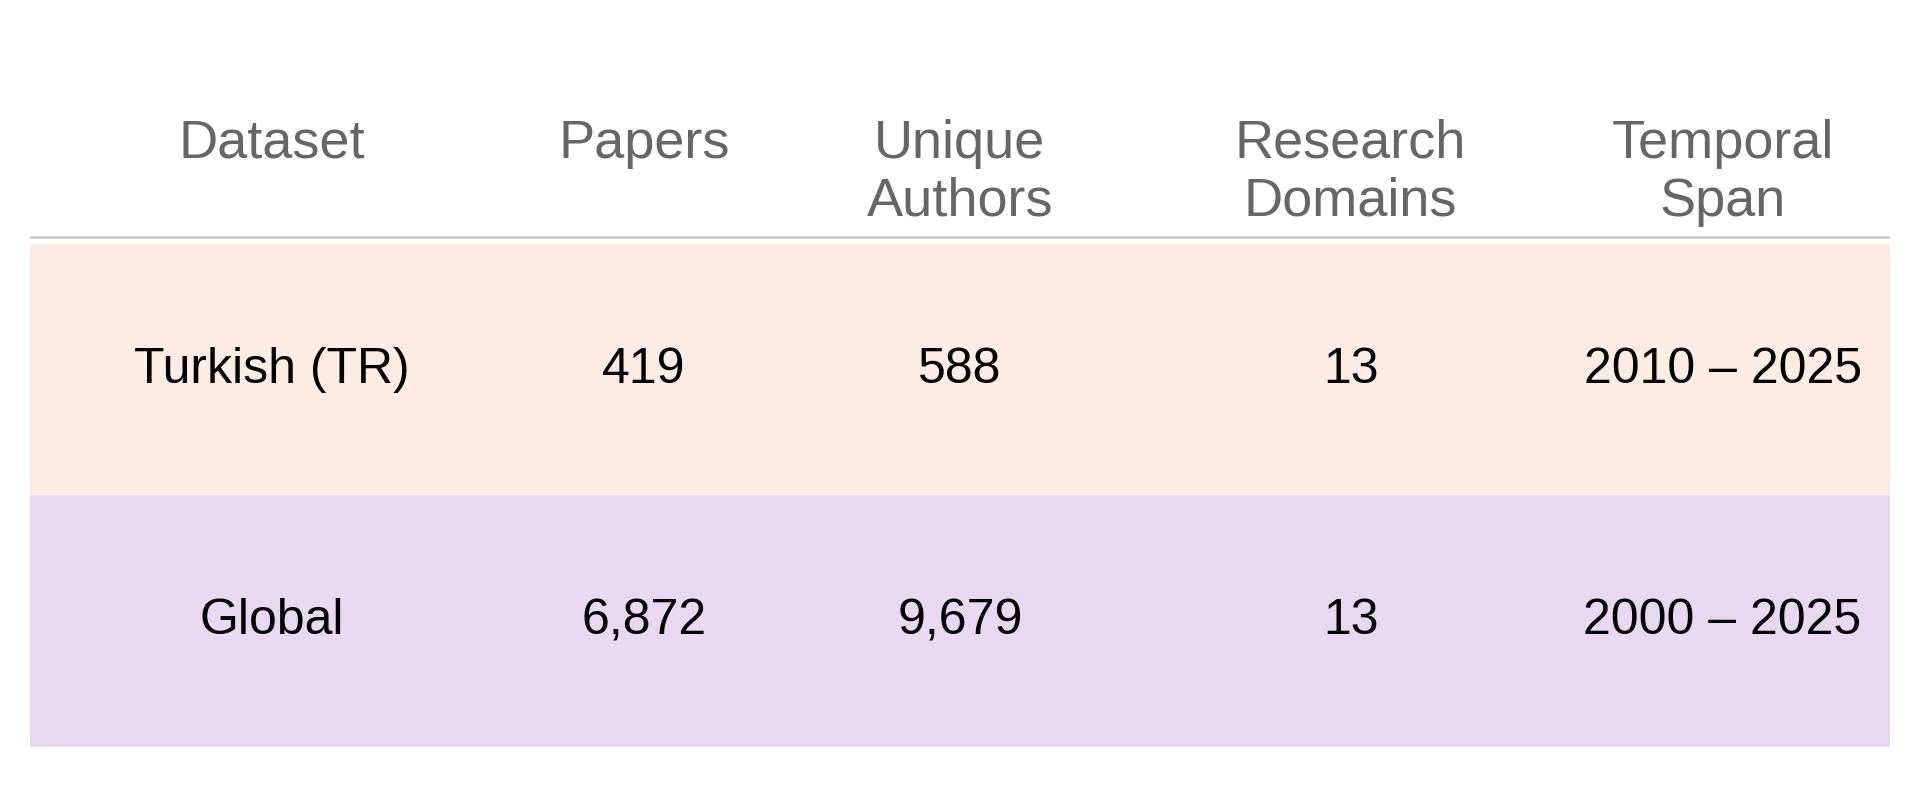

Saved → Dataset_Overview_Table.pdf


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import cm

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

fig, ax = plt.subplots(figsize=(8, 3.2), dpi=300)
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

col_labels = ['Dataset', 'Papers', 'Unique\nAuthors', 'Research\nDomains', 'Temporal\nSpan']
rows = [
    ['Turkish (TR)', '419',   '588',   '13', '2010 – 2025'],
    ['Global',       '6,872', '9,679', '13', '2000 – 2025'],
]

col_widths = [0.26, 0.14, 0.20, 0.22, 0.18]
col_x = [sum(col_widths[:i]) for i in range(len(col_widths))]

color_tr = (*cm.plasma(0.70)[:3], 0.15)
color_gl = (*cm.plasma(0.20)[:3], 0.15)

for label, x, w in zip(col_labels, col_x, col_widths):
    ax.text(x + w / 2, 0.88, label,
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=13, color='#666666',
            fontfamily='sans-serif')

ax.axline((0, 0.72), (1, 0.72), color='#cccccc', linewidth=0.6,
          transform=ax.transAxes)

row_configs = [
    (rows[0], color_tr, 0.38),
    (rows[1], color_gl, 0.04),
]

for row_data, bg_color, y_pos in row_configs:
    ax.add_patch(mpatches.FancyBboxPatch(
        (0, y_pos), 1, 0.32,
        boxstyle="round,pad=0.01",
        transform=ax.transAxes,
        facecolor=bg_color, edgecolor='none',
        zorder=1
    ))

    for cell, x, w in zip(row_data, col_x, col_widths):
        ax.text(x + w / 2, y_pos + 0.16, cell,
                transform=ax.transAxes,
                ha='center', va='center',
                fontsize=12, color='black',
                fontweight='500', fontfamily='sans-serif',
                zorder=2)

plt.savefig('Dataset_Overview_Table.pdf',
            format='pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.savefig('Dataset_Overview_Table.svg',
            format='svg', bbox_inches='tight', transparent=True)
plt.show()
print("Saved → Dataset_Overview_Table.pdf")

/tmp/ipykernel_3915/1324153683.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_3915/1324153683.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


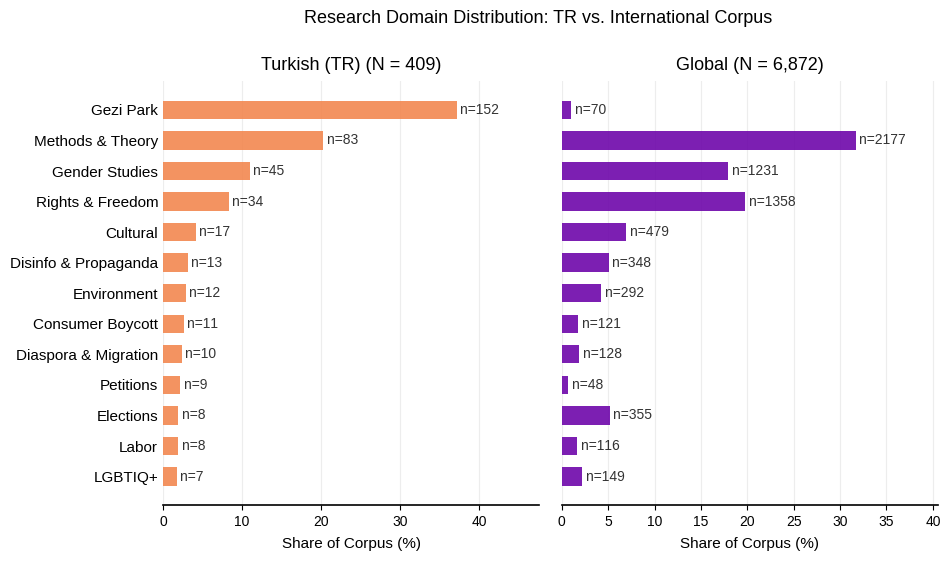

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from collections import Counter

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams['axes.facecolor']  = 'white'

DOMAIN_LABELS = {
    'gezi'               : 'Gezi Park',
    'methods_theory'     : 'Methods & Theory',
    'gender'             : 'Gender Studies',
    'rights_freedom'     : 'Rights & Freedom',
    'disinfo_propaganda' : 'Disinfo & Propaganda',
    'environment'        : 'Environment',
    'cultural'           : 'Cultural',
    'consumer_boycott'   : 'Consumer Boycott',
    'diaspora_migration' : 'Diaspora & Migration',
    'labor'              : 'Labor',
    'elections'          : 'Elections',
    'petitions_changeorg': 'Petitions',
    'lgbtiq'             : 'LGBTIQ+',
}

def domain_counts(articles):
    raw = Counter(
        a.get('research_domain') for a in articles
        if a.get('research_domain') and a.get('research_domain') != 'Unknown'
    )
    return {DOMAIN_LABELS.get(k, k): v for k, v in raw.items()}

def get_papers_with_unknown_domains(articles):
    raw = Counter(
        a.get('research_domain') for a in articles
        if a.get('research_domain') and a.get('research_domain') == 'Unknown'
    )
    return {DOMAIN_LABELS.get(k, k): v for k, v in raw.items()}

counts_tr = domain_counts(articles_tr)
counts_gl = domain_counts(articles_global_pure)

countr_tr_unkown = get_papers_with_unknown_domains(articles_tr)

all_domains = sorted(counts_tr.keys(), key=lambda d: counts_tr.get(d, 0), reverse=True)
n     = len(all_domains)
y_pos = np.arange(n)

tr_vals = np.array([counts_tr.get(d, 0) for d in all_domains], dtype=float)
gl_vals = np.array([counts_gl.get(d, 0) for d in all_domains], dtype=float)
tr_pct  = tr_vals / tr_vals.sum() * 100
gl_pct  = gl_vals / gl_vals.sum() * 100

color_tr = cm.plasma(0.70)
color_gl = cm.plasma(0.20)

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5), dpi=100,
                         gridspec_kw={'wspace': 0.06})

for ax, vals, pct, color, title, total in [
    (axes[0], tr_vals, tr_pct, color_tr, 'Turkish (TR)',  int(tr_vals.sum())),
    (axes[1], gl_vals, gl_pct, color_gl, 'Global',        int(gl_vals.sum())),
]:
    bars = ax.barh(y_pos, pct, height=0.6, color=color, alpha=0.88, zorder=3)

    for bar, count in zip(bars, vals.astype(int)):
        ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
                f'n={count}', va='center', ha='left', fontsize=10, color='#333333')

    ax.set_title(f'{title} (N = {total:,})', fontsize=13, pad=8)
    ax.set_xlabel('Share of Corpus (%)', fontsize=11, labelpad=6)
    ax.set_xlim(0, pct.max() * 1.28)

    if ax is axes[0]:
        ax.set_yticks(y_pos)
        ax.set_yticklabels(all_domains, fontsize=11)
    else:
        ax.set_yticks(y_pos)
        ax.set_yticklabels([])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.2)
    ax.grid(False)
    ax.xaxis.grid(True, linestyle='-', color='lightgray', alpha=0.4, zorder=0)
    ax.tick_params(axis='x', labelsize=10, colors='black')
    ax.tick_params(axis='y', colors='black', length=0)
    ax.invert_yaxis()

plt.suptitle('Research Domain Distribution: TR vs. Global Corpus',
             fontsize=13, y=1.01)
plt.tight_layout()

plt.suptitle('Research Domain Distribution: TR vs. International Corpus',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('Domain_Distribution_TR_vs_Global.pdf',
            format='pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.savefig('Domain_Distribution_TR_vs_Global.svg',
            format='svg', bbox_inches='tight', transparent=True)
plt.show()

/tmp/ipykernel_3915/1173373863.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


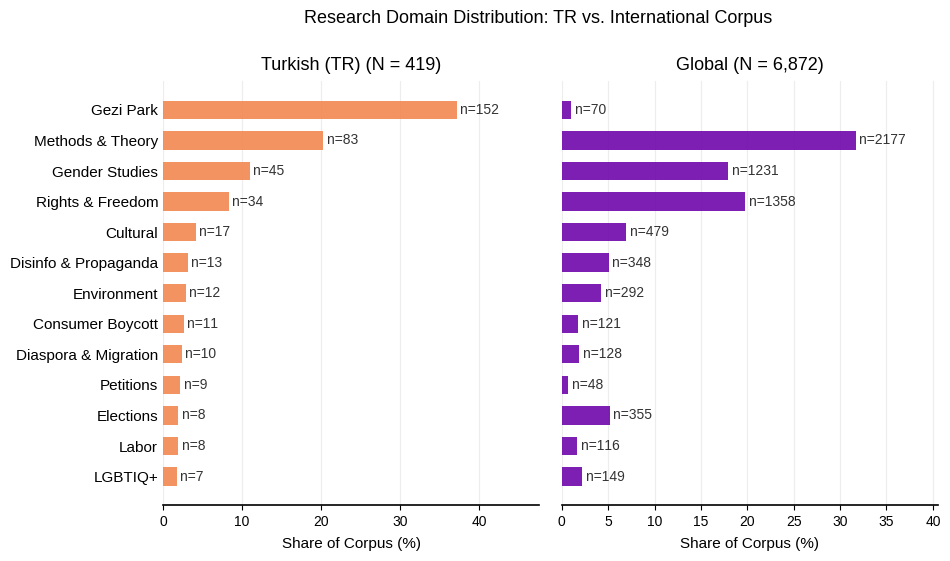

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from collections import Counter

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams['axes.facecolor']  = 'white'

DOMAIN_LABELS = {
    'gezi'               : 'Gezi Park',
    'methods_theory'     : 'Methods & Theory',
    'gender'             : 'Gender Studies',
    'rights_freedom'     : 'Rights & Freedom',
    'disinfo_propaganda' : 'Disinfo & Propaganda',
    'environment'        : 'Environment',
    'cultural'           : 'Cultural',
    'consumer_boycott'   : 'Consumer Boycott',
    'diaspora_migration' : 'Diaspora & Migration',
    'labor'              : 'Labor',
    'elections'          : 'Elections',
    'petitions_changeorg': 'Petitions',
    'lgbtiq'             : 'LGBTIQ+',
}

def domain_counts(articles):
    raw = Counter(
        a.get('research_domain') for a in articles
        if a.get('research_domain') and a.get('research_domain') != 'Unknown'
    )
    return {DOMAIN_LABELS.get(k, k): v for k, v in raw.items()}

counts_tr = domain_counts(articles_tr)
counts_gl = domain_counts(articles_global_pure)

all_domains = sorted(counts_tr.keys(), key=lambda d: counts_tr.get(d, 0), reverse=True)
n     = len(all_domains)
y_pos = np.arange(n)

tr_vals = np.array([counts_tr.get(d, 0) for d in all_domains], dtype=float)
gl_vals = np.array([counts_gl.get(d, 0) for d in all_domains], dtype=float)
tr_pct  = tr_vals / tr_vals.sum() * 100
gl_pct  = gl_vals / gl_vals.sum() * 100

color_tr = cm.plasma(0.70)
color_gl = cm.plasma(0.20)

TR_TOTAL = 419  # total papers including 10 with unknown domain
GL_TOTAL = int(gl_vals.sum())

fig, axes = plt.subplots(1, 2, figsize=(10, 5.5), dpi=100,
                         gridspec_kw={'wspace': 0.06})

for ax, vals, pct, color, title, display_total in [
    (axes[0], tr_vals, tr_pct, color_tr, 'Turkish (TR)', TR_TOTAL),
    (axes[1], gl_vals, gl_pct, color_gl, 'Global',       GL_TOTAL),
]:
    bars = ax.barh(y_pos, pct, height=0.6, color=color, alpha=0.88, zorder=3)

    for bar, count in zip(bars, vals.astype(int)):
        ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
                f'n={count}', va='center', ha='left', fontsize=10, color='#333333')

    ax.set_title(f'{title} (N = {display_total:,})', fontsize=13, pad=8)
    ax.set_xlabel('Share of Corpus (%)', fontsize=11, labelpad=6)
    ax.set_xlim(0, pct.max() * 1.28)

    if ax is axes[0]:
        ax.set_yticks(y_pos)
        ax.set_yticklabels(all_domains, fontsize=11)
    else:
        ax.set_yticks(y_pos)
        ax.set_yticklabels([])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.2)
    ax.grid(False)
    ax.xaxis.grid(True, linestyle='-', color='lightgray', alpha=0.4, zorder=0)
    ax.tick_params(axis='x', labelsize=10, colors='black')
    ax.tick_params(axis='y', colors='black', length=0)
    ax.invert_yaxis()

plt.suptitle('Research Domain Distribution: TR vs. International Corpus',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('Domain_Distribution_TR_vs_Global.pdf',
            format='pdf', bbox_inches='tight', dpi=300, transparent=True)
plt.savefig('Domain_Distribution_TR_vs_Global.svg',
            format='svg', bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
counts_tr

{'LGBTIQ+': 7,
 'Methods & Theory': 83,
 'Gender Studies': 45,
 'Gezi Park': 152,
 'Cultural': 17,
 'Elections': 8,
 'Consumer Boycott': 11,
 'Labor': 8,
 'Diaspora & Migration': 10,
 'Disinfo & Propaganda': 13,
 'Rights & Freedom': 34,
 'Environment': 12,
 'Petitions': 9}

In [ ]:
countr_tr_unkown

{}

## 1. Identifying Intellectual Gatekeepers in Digital Activism Networks

In this section, we identify authors who act as **Intellectual Gatekeepers** (Knowledge Bridges). Unlike authors who are influential within a single thematic silo, these individuals act as the "intellectual glue" of the field, facilitating the flow of ideas between different research domains (e.g., bridging *LGBTI+ Digital Activism* and *Environmental Protest*).

### The Methodology: The Bridge Index ($B_i$)
To isolate these thematic gatekeepers in a **Directed Citation Network**, we utilize a specialized metric that combines citation flow with domain metadata:

1.  **Intellectual Influence ($Z_{bet}$):** We calculate the **Directed Betweenness Centrality** of each author. This measures how frequently an author sits on the "shortest path" of citations between other researchers. We convert this to a **Z-score** to highlight those who are statistically significant bridges relative to the community average.
2.  **Domain Span Potential ($\frac{n(n-1)}{2}$):** If an author is cited by or publishes in $n$ unique research domains (excluding "Unknown"), their potential is calculated based on the possible connections between those domains. This ensures that authors cited only within a single specialized silo are not classified as bridges.
3.  **Relative Bridge Score:** We normalize the final index into a percentage (**0–100%**) relative to the top-scoring author in each dataset. This allows for a fair comparison between the Turkish and Global networks, accounting for differences in total population size.

$$B_i = \max(0, Z_{bet}) \times \frac{n(n-1)}{2}$$

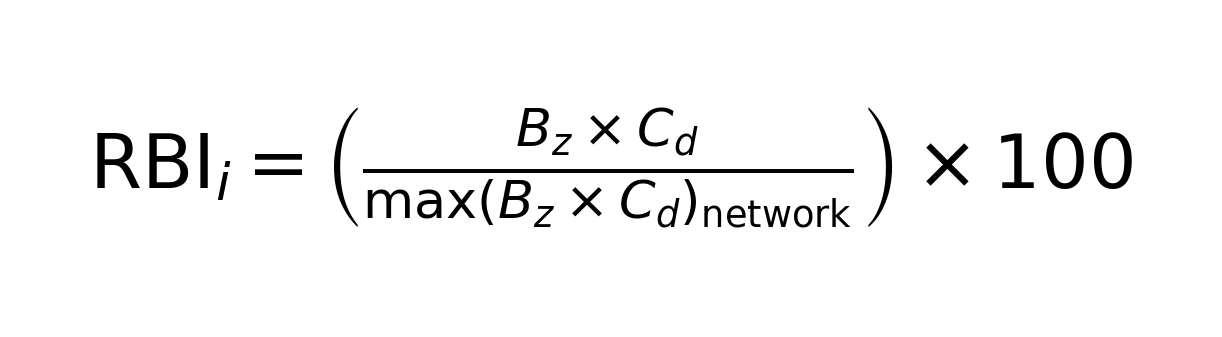

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 1.2), dpi=300)
ax.axis('off')

ax.text(0.5, 0.5,
        r'$\mathrm{RBI}_i = \left(\frac{B_z \times C_d}{\max(B_z \times C_d)_{\mathrm{network}}}\right) \times 100$',
        transform=ax.transAxes,
        ha='center', va='center',
        fontsize=18, color='black')

plt.savefig('RBI_Formula_Main.svg',
            format='svg', bbox_inches='tight', transparent=True)
plt.show()

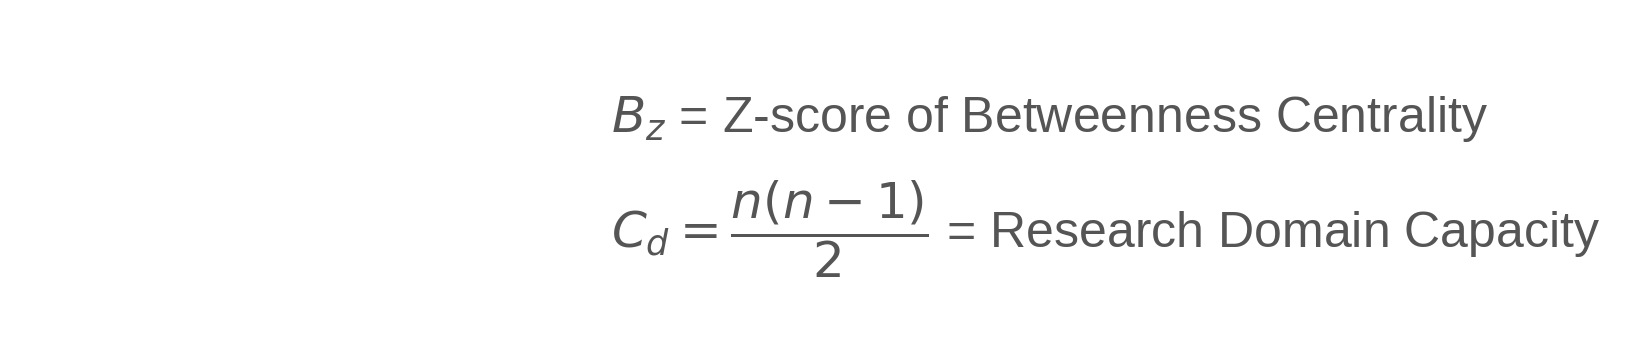

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 1.2), dpi=300)
ax.axis('off')

ax.text(0.5, 0.68,
        r'$B_z$ = Z-score of Betweenness Centrality',
        transform=ax.transAxes,
        ha='left', va='center',
        fontsize=12, color='#555555')

ax.text(0.5, 0.28,
        r'$C_d = \dfrac{n(n-1)}{2}$ = Research Domain Capacity',
        transform=ax.transAxes,
        ha='left', va='center',
        fontsize=12, color='#555555')

plt.savefig('RBI_Formula_Definitions.svg',
            format='svg', bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
def build_id_citation_network(articles, lookup):
    G = nx.DiGraph()

    for art in articles:
        # 1. Get authors of the CURRENT paper
        citing_authors = []
        if art.get('authorships'):
            citing_authors = [a.get('author', {}).get('display_name') for a in art['authorships'] if a.get('author')]

        # 2. Get IDs of the papers it CITES
        referenced_ids = art.get('referenced_works', [])

        for cited_id in referenced_ids:
            # Check if that cited ID is in our lookup table
            if cited_id in lookup:
                cited_authors = lookup[cited_id]

                # 3. Create the intellectual link
                for citing in citing_authors:
                    for cited in cited_authors:
                        if citing and cited and citing != cited:
                            if G.has_edge(citing, cited):
                                G[citing][cited]['weight'] += 1
                            else:
                                G.add_edge(citing, cited, weight=1)

    # Attach domains for Bridge Index
    for art in articles:
        domain = art.get('research_domain', 'Unknown')
        if art.get('authorships'):
            for auth in art['authorships']:
                name = auth.get('author', {}).get('display_name')
                if name and name in G:
                    if 'domains' not in G.nodes[name]:
                        G.nodes[name]['domains'] = set()
                    G.nodes[name]['domains'].add(domain)

    return G

G_tr = build_id_citation_network(articles_tr, tr_lookup)
G_gl = build_id_citation_network(articles_global_pure, global_lookup)

Bridge Index Calculation (Z-Score x Domain Potential)

This function implements the methodology exactly as defined:
1. Calculate Directed Betweenness Centrality.
2. Standardize Betweenness using Z-scores to identify statistical outliers.
3. Apply the Bridge Potential formula: n(n-1)/2.
4. Clip Z-scores at 0 to focus only on positive influencers.
5. Normalize to a 0-100% Relative Bridge Score.

In [ ]:
def calculate_knowledge_bridging_restored(G, articles, network_label):
    print(f"Processing {network_label} Network...")

    # 1. Calculate Raw Betweenness
    bet = nx.betweenness_centrality(G, weight='weight')

    # 2. Calculate Z-scores of these betweenness scores
    bet_values = list(bet.values())
    if len(bet_values) > 1:
        bet_z = zscore(bet_values)
        bet_z_dict = dict(zip(G.nodes(), bet_z))
    else:
        bet_z_dict = {node: 0 for node in G.nodes()}

    # 3. Map authors to their domains (Using OpenAlex Authorship Format)
    author_to_domains = defaultdict(set)
    for art in articles:
        domain = art.get('research_domain', 'Unknown')
        if domain == 'Unknown':
            continue

        # Correctly extract display names from OpenAlex authorship objects
        if art.get('authorships'):
            authors = [a.get('author', {}).get('display_name') for a in art['authorships'] if a.get('author')]
            for a in authors:
                if a:
                    author_to_domains[a].add(domain)

    # 4. Assemble Results
    data = []
    for node in G.nodes():
        doms = author_to_domains.get(node, set())
        n = len(doms)

        # n(n-1)/2: If n=1, potential is 0.
        potential = (n * (n - 1)) / 2

        z = bet_z_dict[node]
        z_clipped = max(0, z) # Only reward positive outliers

        bridge_idx = z_clipped * potential

        data.append({
            'author': node,
            'raw_betweenness': bet[node],
            'betweenness_z': z,
            'domain_count': n,
            'domains': list(doms),
            'bridge_potential': potential,
            'bridge_index': bridge_idx
        })

    df = pd.DataFrame(data)

    # 5. Normalize to Relative Score (0-100)
    max_idx = df['bridge_index'].max()
    df['relative_bridge_score'] = (df['bridge_index'] / max_idx) * 100 if max_idx > 0 else 0

    return df.sort_values('relative_bridge_score', ascending=False)

# --- EXECUTION ---
df_tr_results = calculate_knowledge_bridging_restored(G_tr, articles_tr, "TR")
df_gl_results = calculate_knowledge_bridging_restored(G_gl, articles_global_pure, "GLOBAL")

Processing TR Network...
Processing GLOBAL Network...


In [ ]:
# Verify that n=1 authors now have 0 relative_bridge_score
df_tr_results.head(10)

,author,raw_betweenness,betweenness_z,domain_count,domains,bridge_potential,bridge_index,relative_bridge_score
21,Mustafa Öz,0.004937,10.054992,3,"[rights_freedom, lgbtiq, gezi]",3.0,30.164976,100.000000
78,Christine Ogan,0.002219,4.374537,3,"[gender, diaspora_migration, gezi]",3.0,13.123612,43.506125
23,Erkan Saka,0.002747,5.477899,2,"[gezi, cultural]",1.0,5.477899,18.159799
24,Umut Korkut,0.001748,3.390802,2,"[gezi, diaspora_migration]",1.0,3.390802,11.240857
162,Esra Tani,0.000542,0.868649,2,"[environment, methods_theory]",1.0,0.868649,2.879659
109,Roya Imani Giglou,0.000188,0.129739,2,"[gezi, diaspora_migration]",1.0,0.129739,0.430099
110,Leen d Haenens,0.000188,0.129739,2,"[gezi, diaspora_migration]",1.0,0.129739,0.430099
163,Hatun Boztepe Ta_k1ran,0.000158,0.066853,2,"[environment, methods_theory]",1.0,0.066853,0.221626
172,Hüriye SUBA^I,0.000135,0.019689,2,"[rights_freedom, methods_theory]",1.0,0.019689,0.065271
4,Ryan L. Boyd,0.000000,-0.263298,1,[gender],0.0,0.000000,0.000000


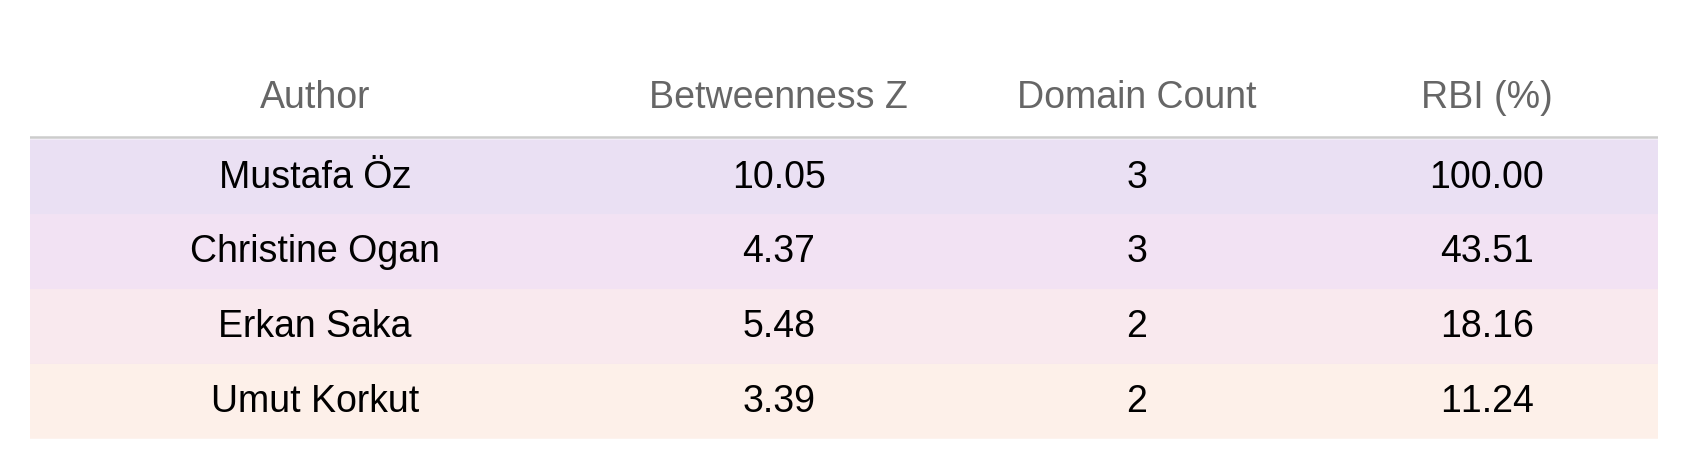

Saved → Bridge_Authors_Table.svg


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import cm

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

authors = [
    ['Mustafa Öz',    '10.05', '3', '100.00'],
    ['Christine Ogan','4.37',  '3', '43.51'],
    ['Erkan Saka',    '5.48',  '2', '18.16'],
    ['Umut Korkut',   '3.39',  '2', '11.24'],
]

col_labels = ['Author', 'Betweenness Z', 'Domain Count', 'RBI (%)']
col_widths  = [0.35, 0.22, 0.22, 0.21]
col_x = [sum(col_widths[:i]) for i in range(len(col_widths))]

n_rows   = len(authors)
row_h    = 0.18
header_y = 0.88
colors   = [cm.plasma(0.15 + 0.55 * (i / (n_rows - 1))) for i in range(n_rows)]

fig, ax = plt.subplots(figsize=(7, 1.8), dpi=300)
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

for label, x, w in zip(col_labels, col_x, col_widths):
    ax.text(x + w / 2, header_y, label,
            transform=ax.transAxes,
            ha='center', va='top',
            fontsize=9, color='#666666',
            fontfamily='sans-serif')

ax.axline((0, 0.74), (1, 0.74), color='#cccccc', linewidth=0.6,
          transform=ax.transAxes)

for i, (row_data, color) in enumerate(zip(authors, colors)):
    y_pos = 0.56 - i * row_h

    bg = (*color[:3], 0.12)
    ax.add_patch(mpatches.FancyBboxPatch(
        (0, y_pos), 1, row_h - 0.01,
        boxstyle="round,pad=0.005",
        transform=ax.transAxes,
        facecolor=bg, edgecolor='none',
        zorder=1
    ))

    for cell, x, w in zip(row_data, col_x, col_widths):
        ax.text(x + w / 2, y_pos + (row_h - 0.01) / 2, cell,
                transform=ax.transAxes,
                ha='center', va='center',
                fontsize=9, color='black',
                fontweight='500', fontfamily='sans-serif',
                zorder=2)

plt.savefig('Bridge_Authors_Table.svg',
            format='svg', bbox_inches='tight', transparent=True)
plt.show()
print("Saved → Bridge_Authors_Table.svg")

In [ ]:
df_gl_results.head(10)

,author,raw_betweenness,betweenness_z,domain_count,domains,bridge_potential,bridge_index,relative_bridge_score
163,Bruce Mutsvairo,0.006410,7.016587,5,"[methods_theory, diaspora_migration, elections...",10.0,70.165872,100.000000
10,Brooke Foucault Welles,0.020773,23.050054,3,"[rights_freedom, methods_theory, gender]",3.0,69.150161,98.552414
99,Tanja Bosch,0.007347,8.062128,4,"[rights_freedom, cultural, elections, gender]",6.0,48.372769,68.940594
791,Saifuddin Ahmed,0.006340,6.938573,4,"[gender, elections, methods_theory, rights_fre...",6.0,41.631438,59.332888
35,Merlyna Lim,0.006228,6.814002,4,"[gender, cultural, methods_theory, disinfo_pro...",6.0,40.884009,58.267657
177,Summer Harlow,0.010533,11.619088,3,"[rights_freedom, methods_theory, gender]",3.0,34.857263,49.678372
264,Yunhwan Kim,0.009801,10.801613,3,"[gender, methods_theory, disinfo_propaganda]",3.0,32.404840,46.183193
363,Innocent Chiluwa,0.009438,10.396969,3,"[rights_freedom, labor, gender]",3.0,31.190908,44.453104
80,Emiliano Treré,0.009406,10.360810,3,"[environment, cultural, methods_theory]",3.0,31.082431,44.298504
11,Jennifer Earl,0.025874,28.744353,2,"[petitions_changeorg, methods_theory]",1.0,28.744353,40.966288


### Intellectual Bridge Distribution (Rank-Frequency Plot)

This plot visualizes the hierarchy of intellectual gatekeeping in both networks.
We use a high-contrast grayscale palette:
- Dark Slate (#4D4D4D) for the Turkish Network.
- Light Ash (#A6A6A6) for the Global Network.

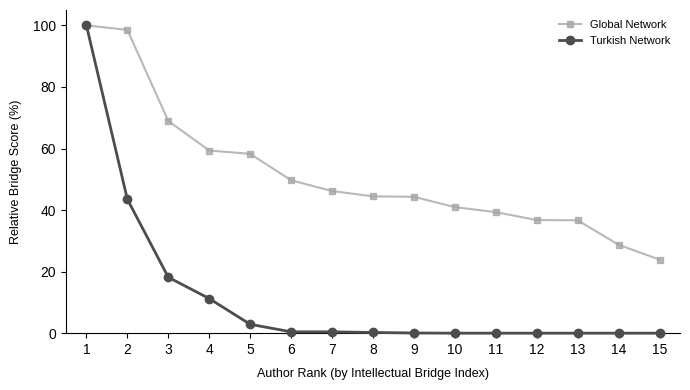

In [ ]:
def generate_minimalist_line_plot_gray(df_tr, df_global, filename="Intellectual_Bridge_Distribution.pdf"):
    plt.rcParams['axes.facecolor'] = 'white'
    fig, ax = plt.subplots(figsize=(7, 4), dpi=100)

    top_n = 15
    tr_scores = df_tr['relative_bridge_score'].head(top_n).values
    gl_scores = df_global['relative_bridge_score'].head(top_n).values
    ranks = range(1, top_n + 1)

    # 1. ADDED 'zorder': Higher numbers appear 'on top'
    # 2. ADDED 'clip_on=False': Prevents dots from being cut off by the axis
    ax.plot(ranks, gl_scores, marker='s', markersize=5, color='#A6A6A6',
            linewidth=1.5, label='Global Network', clip_on=False, alpha=0.8, zorder=2)

    ax.plot(ranks, tr_scores, marker='o', markersize=6, color='#4D4D4D',
            linewidth=2, label='Turkish Network', clip_on=False, zorder=3)

    ax.set_xlabel("Author Rank (by Intellectual Bridge Index)", fontsize=9, labelpad=8)
    ax.set_ylabel("Relative Bridge Score (%)", fontsize=9, labelpad=8)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

    # 3. ADJUSTED X-LIMITS: Adding 0.5 padding so the first dot isn't on the Y-axis
    ax.set_xlim(0.5, top_n + 0.5)
    ax.set_xticks(ranks)
    ax.set_ylim(0, 105)

    ax.legend(frameon=False, loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()

# Execution
generate_minimalist_line_plot_gray(df_tr_results, df_gl_results)

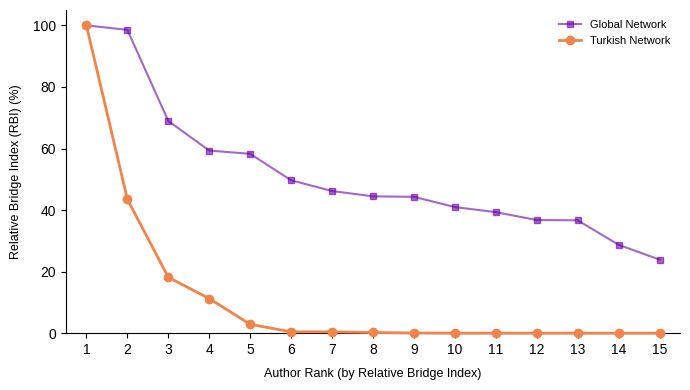

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.font_manager as fm

def generate_minimalist_line_plot_plasma(df_tr, df_global, filename="Intellectual_Bridge_Distribution.pdf"):
    # --- FONT CONFIGURATION ---
    # Attempt to set Arial, fallback to sans-serif
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

    # Set the background to white
    plt.rcParams['axes.facecolor'] = 'white'
    fig, ax = plt.subplots(figsize=(7, 4), dpi=100)

    top_n = 15
    tr_scores = df_tr['relative_bridge_score'].head(top_n).values
    gl_scores = df_global['relative_bridge_score'].head(top_n).values
    ranks = range(1, top_n + 1)

    # Plasma palette colors
    color_global = cm.plasma(0.2)
    color_tr = cm.plasma(0.7)

    # Plotting
    ax.plot(ranks, gl_scores, marker='s', markersize=5, color=color_global,
            linewidth=1.5, label='Global Network', clip_on=False, alpha=0.6, zorder=2)

    ax.plot(ranks, tr_scores, marker='o', markersize=6, color=color_tr,
            linewidth=2, label='Turkish Network', clip_on=False, zorder=3)

    # Standardized Labeling with Arial
    ax.set_xlabel("Author Rank (by Relative Bridge Index)", fontsize=9, labelpad=8)
    ax.set_ylabel("Relative Bridge Index (RBI) (%)", fontsize=9, labelpad=8)

    # Aesthetic cleaning
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

    # Axis limits and ticks
    ax.set_xlim(0.5, top_n + 0.5)
    ax.set_xticks(ranks)
    ax.set_ylim(0, 105)

    # Legend
    ax.legend(frameon=False, loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()

generate_minimalist_line_plot_plasma(df_tr_results, df_gl_results)

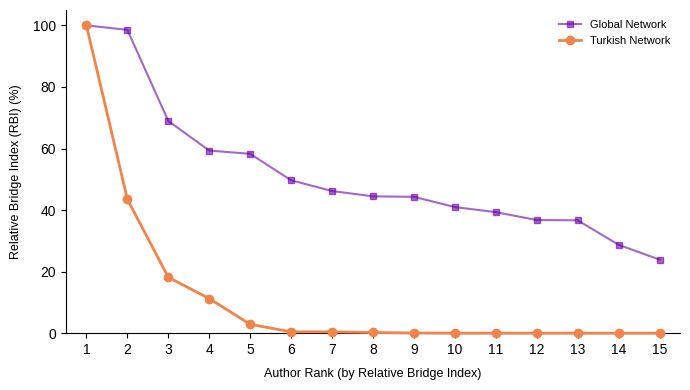

Saved → Intellectual_Bridge_Distribution.svg


In [ ]:
def generate_minimalist_line_plot_plasma(df_tr, df_global, filename="Intellectual_Bridge_Distribution.svg"):
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
    plt.rcParams['axes.facecolor'] = 'white'

    fig, ax = plt.subplots(figsize=(7, 4), dpi=100)

    top_n = 15
    tr_scores = df_tr['relative_bridge_score'].head(top_n).values
    gl_scores = df_global['relative_bridge_score'].head(top_n).values
    ranks = range(1, top_n + 1)

    color_global = cm.plasma(0.2)
    color_tr     = cm.plasma(0.7)

    ax.plot(ranks, gl_scores, marker='s', markersize=5, color=color_global,
            linewidth=1.5, label='Global Network', clip_on=False, alpha=0.6, zorder=2)
    ax.plot(ranks, tr_scores, marker='o', markersize=6, color=color_tr,
            linewidth=2, label='Turkish Network', clip_on=False, zorder=3)

    ax.set_xlabel("Author Rank (by Relative Bridge Index)", fontsize=9, labelpad=8)
    ax.set_ylabel("Relative Bridge Index (RBI) (%)", fontsize=9, labelpad=8)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

    ax.set_xlim(0.5, top_n + 0.5)
    ax.set_xticks(ranks)
    ax.set_ylim(0, 105)

    ax.legend(frameon=False, loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.savefig(filename, format='svg', bbox_inches='tight')
    plt.show()

generate_minimalist_line_plot_plasma(df_tr_results, df_gl_results)
print("Saved → Intellectual_Bridge_Distribution.svg")

### Exporting the Intellectual Map (GEXF)

We export the directed citation network to GEXF format.
Each node will carry its:
1. Relative Bridge Score (for sizing)
2. Domain Count (for coloring)
3. Primary Research Domains

In [ ]:
def export_to_gephi_directed(G, df_results, filename):
    # Create a local copy to avoid modifying the original graph
    G_export = G.copy()

    # Map the results from our dataframe back onto the graph nodes
    # We use the author name as the key
    results_dict = df_results.set_index('author').to_dict('index')

    for node in G_export.nodes():
        if node in results_dict:
            res = results_dict[node]
            G_export.nodes[node]['relative_bridge_score'] = float(res['relative_bridge_score'])
            G_export.nodes[node]['domain_count'] = int(res['domain_count'])
            # Gephi likes strings for lists of attributes
            G_export.nodes[node]['domains'] = ", ".join(res['domains'])
        else:
            # Fallback for nodes that might have been filtered or have 0 score
            G_export.nodes[node]['relative_bridge_score'] = 0.0
            G_export.nodes[node]['domain_count'] = 0
            G_export.nodes[node]['domains'] = "None"

    nx.write_gexf(G_export, filename)
    print(f"Success! {filename} is ready for Gephi.")

# Execution
export_to_gephi_directed(G_tr, df_tr_results, "Turkish_Intellectual_Bridges.gexf")
export_to_gephi_directed(G_gl, df_gl_results, "Global_Intellectual_Bridges.gexf")

Success! Turkish_Intellectual_Bridges.gexf is ready for Gephi.
Success! Global_Intellectual_Bridges.gexf is ready for Gephi.


In [ ]:
def export_to_gephi_with_edge_domains(articles, lookup, df_results, filename):
    # We build a fresh graph to ensure all attributes are correctly attached
    G = nx.DiGraph()

    # 1. ADD EDGES WITH DOMAINS
    for art in articles:
        domain = art.get('research_domain', 'Unknown')
        citing_authors = [a.get('author', {}).get('display_name') for a in art.get('authorships', []) if a.get('author')]
        referenced_ids = art.get('referenced_works', [])

        for cited_id in referenced_ids:
            if cited_id in lookup:
                cited_authors = lookup[cited_id]
                for citing in citing_authors:
                    for cited in cited_authors:
                        if citing and cited and citing != cited:
                            # ATTACH DOMAIN TO THE EDGE
                            if G.has_edge(citing, cited):
                                G[citing][cited]['weight'] += 1
                                # Append domain if it's a new one for this connection
                                current_domains = G[citing][cited].get('research_domain', "")
                                if domain not in current_domains:
                                    G[citing][cited]['research_domain'] = current_domains + ", " + domain
                            else:
                                G.add_edge(citing, cited, weight=1, research_domain=domain)

    # 2. ADD NODE ATTRIBUTES (Bridge Scores)
    results_dict = df_results.set_index('author').to_dict('index')
    for node in G.nodes():
        if node in results_dict:
            res = results_dict[node]
            G.nodes[node]['relative_bridge_score'] = float(res['relative_bridge_score'])
            G.nodes[node]['domain_count'] = int(res['domain_count'])
            G.nodes[node]['domains'] = ", ".join(res['domains'])
        else:
            G.nodes[node]['relative_bridge_score'] = 0.0
            G.nodes[node]['domain_count'] = 0

    nx.write_gexf(G, filename)
    print(f"Fixed! {filename} now contains Edge Domains.")

# Execution
export_to_gephi_with_edge_domains(articles_tr, tr_lookup, df_tr_results, "Turkish_Intellectual_Bridges_FINAL.gexf")
export_to_gephi_with_edge_domains(articles_global_pure, global_lookup, df_gl_results, "Global_Intellectual_Bridges_FINAL.gexf")

Fixed! Turkish_Intellectual_Bridges_FINAL.gexf now contains Edge Domains.
Fixed! Global_Intellectual_Bridges_FINAL.gexf now contains Edge Domains.


## 2. Intellectual Fragility: The "Bridge Collapse" Stress Test

In this section, we evaluate the structural resilience of the research community. We simulate a 'Targeted Attack' by removing the top Intellectual Gatekeepers (ranked by Bridge Index) and monitor the 'Giant Component'—the largest cluster of connected researchers.

**Scientific Goal:** To determine if the intellectual coherence of the Turkish field is dangerously dependent on a few individuals, or if the community is robust enough to maintain a unified discourse without them.

In [ ]:
import random

def simulate_network_fragility(G, df_results, network_label, seed=42):
    """
    Simulates network collapse by removing nodes and measuring connectivity.
    Includes a random seed for reproducible 'Random Attrition' baselines.
    """
    # Create copies of the graph for the two scenarios
    g_targeted = G.copy()
    g_random = G.copy()

    # 1. FIX THE SEED: This ensures the 'Random' shuffle is the same every time
    rng = random.Random(seed)

    # 2. PREPARE NODE LISTS
    # Targeted: Use our calculated Bridge Index ranking
    target_nodes = df_results['author'].tolist()

    # Random: Start with all nodes and shuffle them using our seeded RNG
    random_nodes = list(G.nodes())
    rng.shuffle(random_nodes)

    # We will remove up to 20% of the network or top 50 authors
    limit = min(50, int(len(G.nodes()) * 0.2))

    results = []

    def get_giant_component_ratio(graph):
        if len(graph) == 0: return 0
        # Weakly connected components capture 'reachability' in citation networks
        components = sorted(nx.weakly_connected_components(graph), key=len, reverse=True)
        return len(components[0]) / len(G.nodes()) if components else 0

    # Record initial state (0 nodes removed)
    results.append({
        'nodes_removed': 0,
        'targeted_ratio': get_giant_component_ratio(g_targeted),
        'random_ratio': get_giant_component_ratio(g_random),
        'network': network_label
    })

    # 3. RUN THE SIMULATION
    for i in range(limit):
        if i < len(target_nodes):
            g_targeted.remove_node(target_nodes[i])
        if i < len(random_nodes):
            g_random.remove_node(random_nodes[i])

        results.append({
            'nodes_removed': i + 1,
            'targeted_ratio': get_giant_component_ratio(g_targeted),
            'random_ratio': get_giant_component_ratio(g_random),
            'network': network_label
        })

    return pd.DataFrame(results)

# --- EXECUTION ---
# Using the same seed for both ensures the 'randomness' is consistent across networks
fragility_tr = simulate_network_fragility(G_tr, df_tr_results, "TR", seed=42)
fragility_gl = simulate_network_fragility(G_gl, df_gl_results, "GLOBAL", seed=42)

print("Simulation complete with seed=42. Your results are now reproducible.")

Simulation complete with seed=42. Your results are now reproducible.


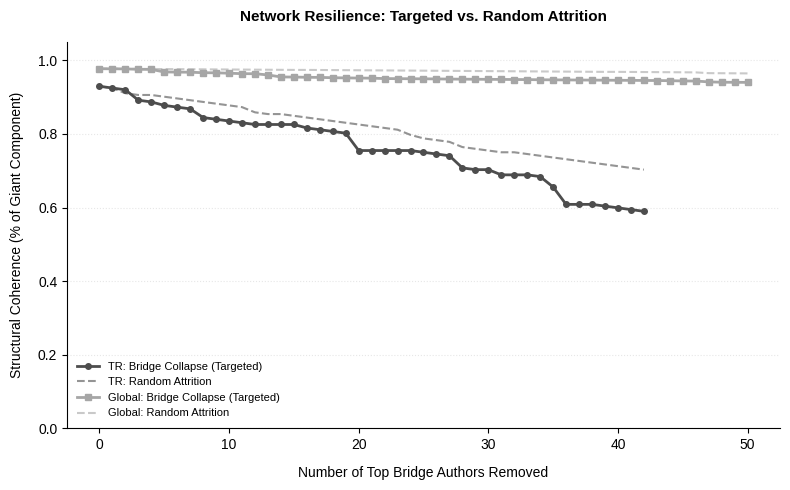

In [ ]:
def plot_fragility_comparison_v2(df_tr, df_gl):
    plt.rcParams['axes.facecolor'] = 'white'
    fig, ax = plt.subplots(figsize=(8, 5), dpi=100)

    # --- TURKISH NETWORK ---
    # Targeted (Solid Dark)
    ax.plot(df_tr['nodes_removed'], df_tr['targeted_ratio'], 'o-', color='#4D4D4D',
            linewidth=2, label='TR: Bridge Collapse (Targeted)', markersize=4, zorder=4)
    # Random (Dashed Dark)
    ax.plot(df_tr['nodes_removed'], df_tr['random_ratio'], '--', color='#4D4D4D',
            alpha=0.6, label='TR: Random Attrition', linewidth=1.5, zorder=3)

    # --- GLOBAL NETWORK ---
    # Targeted (Solid Light)
    ax.plot(df_gl['nodes_removed'], df_gl['targeted_ratio'], 's-', color='#A6A6A6',
            linewidth=2, label='Global: Bridge Collapse (Targeted)', markersize=4, zorder=2)
    # Random (Dashed Light)
    ax.plot(df_gl['nodes_removed'], df_gl['random_ratio'], '--', color='#A6A6A6',
            alpha=0.6, label='Global: Random Attrition', linewidth=1.5, zorder=1)

    # Formatting for a High-Impact Journal
    ax.set_xlabel("Number of Top Bridge Authors Removed", fontsize=10, labelpad=10)
    ax.set_ylabel("Structural Coherence (% of Giant Component)", fontsize=10, labelpad=10)
    ax.set_title("Network Resilience: Targeted vs. Random Attrition", fontsize=11, fontweight='bold', pad=15)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.3)
    ax.set_ylim(0, 1.05)

    # Legend outside or in a clean spot
    ax.legend(frameon=False, fontsize=8, loc='best')

    plt.tight_layout()
    plt.savefig("Intellectual_Resilience_Final.pdf", format='pdf', dpi=300)
    plt.show()

# Execution
plot_fragility_comparison_v2(fragility_tr, fragility_gl)

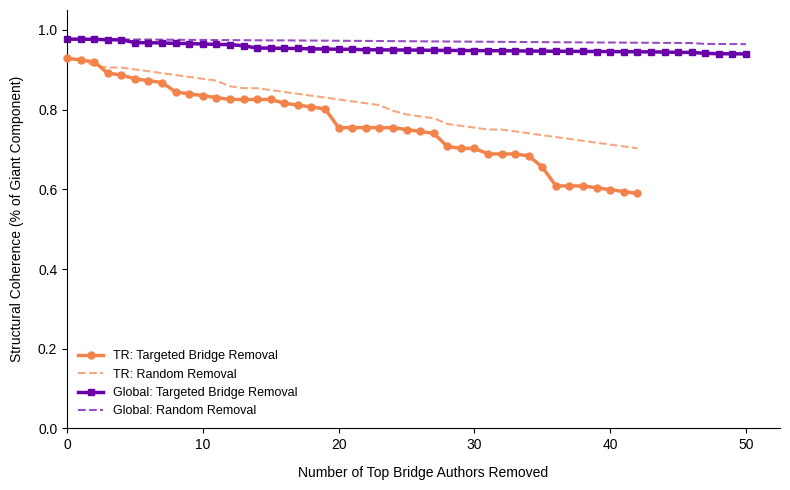

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm

def plot_fragility_comparison_plasma(df_tr, df_gl, filename="Intellectual_Resilience_Final.pdf"):
    # --- FONT CONFIGURATION ---
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
    plt.rcParams['axes.facecolor'] = 'white'

    fig, ax = plt.subplots(figsize=(8, 5), dpi=100)

    # Standardizing colors from the Plasma palette
    color_gl = cm.plasma(0.2) # Deep Purple/Indigo
    color_tr = cm.plasma(0.7) # Vibrant Magenta/Orange

    # --- TURKISH NETWORK ---
    # Targeted (Solid - The main story)
    ax.plot(df_tr['nodes_removed'], df_tr['targeted_ratio'], 'o-', color=color_tr,
            linewidth=2.5, label='TR: Targeted Bridge Removal', markersize=5, zorder=4, clip_on=False)
    # Random (Dashed - The baseline)
    ax.plot(df_tr['nodes_removed'], df_tr['random_ratio'], '--', color=color_tr,
            alpha=0.7, label='TR: Random Removal', linewidth=1.5, zorder=3)

    # --- GLOBAL NETWORK ---
    # Targeted (Solid)
    ax.plot(df_gl['nodes_removed'], df_gl['targeted_ratio'], 's-', color=color_gl,
            linewidth=2.5, label='Global: Targeted Bridge Removal', markersize=5, zorder=2, clip_on=False)
    # Random (Dashed)
    ax.plot(df_gl['nodes_removed'], df_gl['random_ratio'], '--', color=color_gl,
            alpha=0.7, label='Global: Random Removal', linewidth=1.5, zorder=1)

    # Formatting
    ax.set_xlabel("Number of Top Bridge Authors Removed", fontsize=10, labelpad=10)
    ax.set_ylabel("Structural Coherence (% of Giant Component)", fontsize=10, labelpad=10)

    # Minimalist aesthetics
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False) # Removed grid per your previous preference

    ax.set_ylim(0, 1.05)
    ax.set_xlim(left=0)

    # Legend - placed to not overlap with the lines
    ax.legend(frameon=False, fontsize=9, loc='lower left')

    plt.tight_layout()
    plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
    plt.savefig('Intellectual_Resilience_Final.svg', format='svg', bbox_inches='tight', transparent=True)
    plt.show()

plot_fragility_comparison_plasma(fragility_tr, fragility_gl)

**Finding:** The simulation reveals a nuanced structural reality: while the Turkish network is significantly more sensitive to targeted attacks than the global baseline—demonstrating the outsized influence of 'Bridge Authors', it stops short of total fragmentation. This suggests that the Turkish digital activism field possesses a latent structural robustness. Even in the absence of its primary intellectual gatekeepers, the community remains anchored by a dense web of shared references, likely facilitated by the centralizing force of the Gezi Park protests.

## 3. Knowledge Diffusion & the Small-World Phenomenon

This section measures the "Intellectual Velocity" of the network. We analyze how efficiently
information travels across disciplinary boundaries by calculating the average distance between
any two researchers in the field.

In [ ]:
def calculate_small_world_metrics(G, label):
    # We must use the Weakly Connected Giant Component for distance metrics
    gc_nodes = max(nx.weakly_connected_components(G), key=len)
    GC = G.subgraph(gc_nodes).to_undirected() # Distance is easier to grasp as undirected paths

    print(f"--- Analytics for {label} (Giant Component) ---")

    # 1. Average Path Length (How many 'hops' between authors)
    path_len = nx.average_shortest_path_length(GC)

    # 2. Clustering Coefficient (How 'tight' the community is)
    clustering = nx.average_clustering(GC)

    # 3. Network Diameter (The furthest distance between any two people)
    diameter = nx.diameter(GC)

    return {
        "Network": label,
        "Avg Path Length": round(path_len, 2),
        "Clustering": round(clustering, 3),
        "Diameter": diameter,
        "Size": len(GC.nodes())
    }

# Execution
stats_tr = calculate_small_world_metrics(G_tr, "Turkish Network")
stats_gl = calculate_small_world_metrics(G_gl, "Global Network")

# Display as a clean Table
df_stats = pd.DataFrame([stats_tr, stats_gl])
print(df_stats)

--- Analytics for Turkish Network (Giant Component) ---
--- Analytics for Global Network (Giant Component) ---
           Network  Avg Path Length  Clustering  Diameter  Size
0  Turkish Network             4.89       0.146        12   197
1   Global Network             3.64       0.224         9  4237


#### **1. The Efficiency Paradox**
Counter-intuitively, the **Global Network** is more efficient at diffusing information than the **Turkish Network**, despite being 20 times larger. With a path length of only $3.64$, the global field acts as a **"Tight-Knit Metropolis"** where information flows rapidly through a dense, redundant system of citations.

#### **2. The "Intellectual Archipelago"**
In contrast, the Turkish network behaves like an **"Archipelago"**—a collection of separate islands. With a higher path length ($4.89$) and a larger diameter ($12$), it takes more "hops" for an idea to travel from one specialized sub-domain (e.g., Diaspora Studies) to another (e.g., Big Data Analytics).



#### **3. Sparse Cohesion**
The lower clustering coefficient ($0.146$ vs $0.224$) suggests a lack of "redundant shortcuts" in the Turkish network. While the global field is woven together in dense cliques, the Turkish field is more sparse, with researchers often working in specialized silos that lack mutual citation links.

### **Scientific Significance: Why Bridges Matter**
This fragmentation explains exactly why the **Bridge Authors** identified in Chapter 1 are so vital. In a sparse "Archipelago," the bridges are the primary infrastructure connecting the islands. They act as the "high-speed ferries" between distant research domains.

Without these specific individuals, the Turkish digital activism discourse would likely dissolve into isolated silos, losing the multidisciplinary synthesis required to evolve as a unified academic field.

In [ ]:
import networkx as nx
import pandas as pd

def iterative_small_world_analysis(G, df_results, network_name="Network", top_n=4):
    G_un = G.to_undirected()

    # Identify top authors from the table
    top_bridges = df_results.sort_values(by='relative_bridge_score', ascending=False).head(top_n)
    bridge_names = top_bridges['author'].tolist()

    # --- NODE DISCOVERY ---
    # We find the actual node IDs in the graph that match these names
    name_to_id = {data.get('name', n): n for n, data in G_un.nodes(data=True)}
    bridge_ids = [name_to_id.get(name) for name in bridge_names]

    # Filter out any names that weren't found in the graph to avoid the KeyError
    valid_bridges = [(name, b_id) for name, b_id in zip(bridge_names, bridge_ids) if b_id is not None]

    stats = []

    # Step 0: Baseline
    current_G = G_un.copy()
    main_cc = current_G.subgraph(max(nx.connected_components(current_G), key=len)).copy()
    stats.append({
        "Removed": "Baseline",
        "APL": nx.average_shortest_path_length(main_cc),
        "Diameter": nx.diameter(main_cc),
        "CC_Size": len(main_cc)
    })

    # Step 1-N: Iterative Removal
    for name, b_id in valid_bridges:
        if b_id in current_G:
            current_G.remove_node(b_id)
            components = list(nx.connected_components(current_G))
            if not components: break

            main_cc = current_G.subgraph(max(components, key=len)).copy()

            stats.append({
                "Removed": name,
                "APL": nx.average_shortest_path_length(main_cc),
                "Diameter": nx.diameter(main_cc),
                "CC_Size": len(main_cc)
            })

    df_stats = pd.DataFrame(stats)
    print(f"\n--- Iterative Small-World Impact: {network_name} ---")
    print(df_stats.to_string(index=False))
    return df_stats

tr_iterative = iterative_small_world_analysis(G_tr, df_tr_results, "Turkish")


--- Iterative Small-World Impact: Turkish ---
       Removed      APL  Diameter  CC_Size
      Baseline 4.887444        12      197
    Mustafa Öz 4.915699        12      196
Christine Ogan 4.954533        12      195
    Erkan Saka 4.969155        12      189
   Umut Korkut 5.763511        14      188


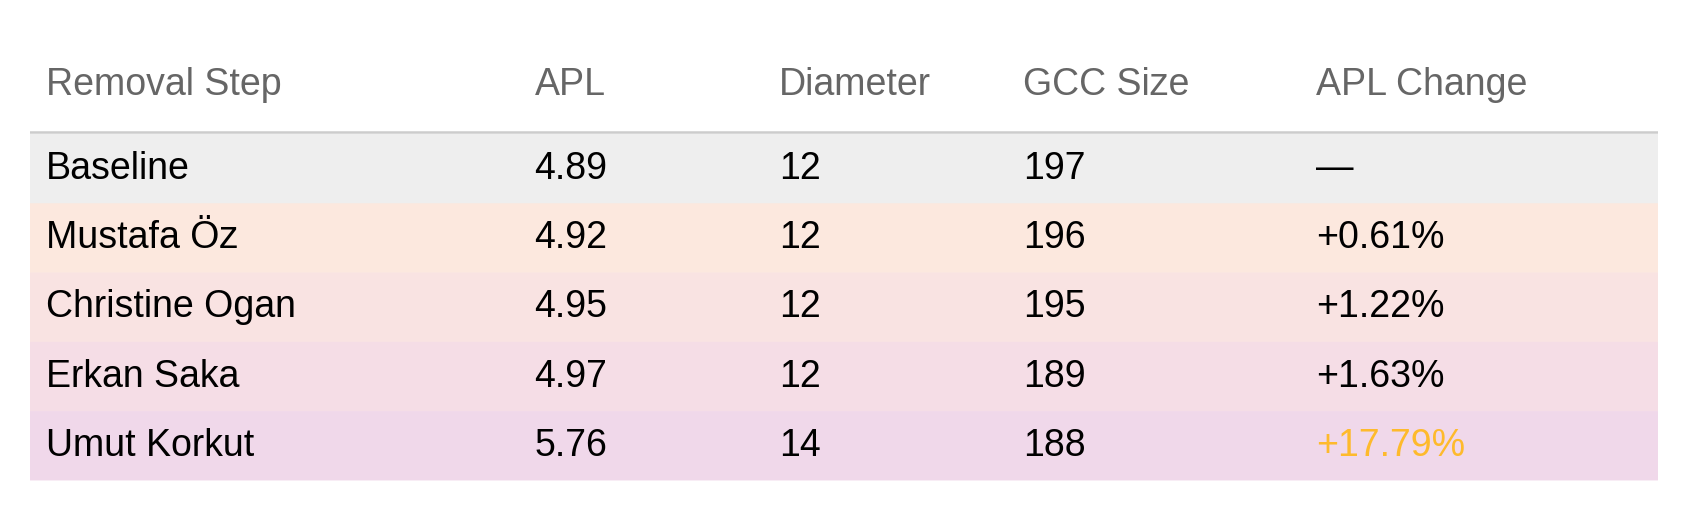

Saved → SmallWorld_Impact_Table.svg


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import cm

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']

rows = [
    ['Baseline',        '4.89', '12', '197', '—'],
    ['Mustafa Öz',    '4.92', '12', '196', '+0.61%'],
    ['Christine Ogan','4.95', '12', '195', '+1.22%'],
    ['Erkan Saka',    '4.97', '12', '189', '+1.63%'],
    ['Umut Korkut',   '5.76', '14', '188', '+17.79%'],
]

col_labels = ['Removal Step', 'APL', 'Diameter', 'GCC Size', 'APL Change']
col_widths  = [0.30, 0.15, 0.15, 0.18, 0.22]
col_x = [sum(col_widths[:i]) for i in range(len(col_widths))]

n_rows = len(rows)
row_h  = 0.15

row_colors = [
    (0.75, 0.75, 0.75, 0.25),
    (*cm.plasma(0.70)[:3], 0.18),
    (*cm.plasma(0.60)[:3], 0.18),
    (*cm.plasma(0.50)[:3], 0.18),
    (*cm.plasma(0.40)[:3], 0.18),
]

fig, ax = plt.subplots(figsize=(7, 2.0), dpi=300)
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

for label, x, w in zip(col_labels, col_x, col_widths):
    ax.text(x + 0.01, 0.92, label,
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=9, color='#666666',
            fontfamily='sans-serif')

ax.axline((0, 0.78), (1, 0.78), color='#cccccc', linewidth=0.6,
          transform=ax.transAxes)

for i, (row_data, color) in enumerate(zip(rows, row_colors)):
    y_pos = 0.63 - i * row_h

    ax.add_patch(mpatches.FancyBboxPatch(
        (0, y_pos), 1, row_h - 0.01,
        boxstyle="round,pad=0.005",
        transform=ax.transAxes,
        facecolor=color, edgecolor='none',
        zorder=1
    ))

    for j, (cell, x, w) in enumerate(zip(row_data, col_x, col_widths)):
        text_color = cm.plasma(0.85)[:3] if (i == n_rows - 1 and j == 4) else 'black'
        ax.text(x + 0.01, y_pos + (row_h - 0.01) / 2, cell,
                transform=ax.transAxes,
                ha='left', va='center',
                fontsize=9, color=text_color,
                fontweight='500' if i == 0 else 'normal',
                fontfamily='sans-serif',
                zorder=2)

plt.savefig('SmallWorld_Impact_Table.svg',
            format='svg', bbox_inches='tight', transparent=True)
plt.show()
print("Saved → SmallWorld_Impact_Table.svg")

In [ ]:
import networkx as nx
import pandas as pd

def iterative_small_world_analysis(G, df_results, network_name="Network", top_n=4):
    G_un = G.to_undirected()

    # Identify top authors from the table
    top_bridges = df_results.sort_values(by='relative_bridge_score', ascending=False).head(top_n)
    bridge_names = top_bridges['author'].tolist()

    # --- NODE DISCOVERY ---
    name_to_id = {data.get('name', n): n for n, data in G_un.nodes(data=True)}
    bridge_ids = [name_to_id.get(name) for name in bridge_names]
    valid_bridges = [(name, b_id) for name, b_id in zip(bridge_names, bridge_ids) if b_id is not None]

    stats = []

    # Step 0: Baseline — find anchor node from the original GCC
    current_G = G_un.copy()
    original_gcc_nodes = max(nx.connected_components(current_G), key=len)
    anchor_node = list(original_gcc_nodes)[0]

    main_cc = current_G.subgraph(
        nx.node_connected_component(current_G, anchor_node)
    ).copy()

    baseline_apl = nx.average_shortest_path_length(main_cc)
    stats.append({
        "Removed"   : "Baseline",
        "APL"       : baseline_apl,
        "Diameter"  : nx.diameter(main_cc),
        "CC_Size"   : len(main_cc),
        "APL_Change": "—"
    })

    # Step 1-N: Iterative Removal — always follow the anchor node
    for name, b_id in valid_bridges:
        if b_id in current_G:
            current_G.remove_node(b_id)

            # If anchor node itself got removed, pick a new one from remaining nodes
            if anchor_node not in current_G:
                components = list(nx.connected_components(current_G))
                if not components:
                    break
                anchor_node = list(max(components, key=len))[0]

            main_cc = current_G.subgraph(
                nx.node_connected_component(current_G, anchor_node)
            ).copy()

            new_apl = nx.average_shortest_path_length(main_cc)
            apl_change = ((new_apl - baseline_apl) / baseline_apl) * 100

            stats.append({
                "Removed"   : name,
                "APL"       : round(new_apl, 6),
                "Diameter"  : nx.diameter(main_cc),
                "CC_Size"   : len(main_cc),
                "APL_Change": f"+{apl_change:.2f}%"
            })

    df_stats = pd.DataFrame(stats)
    print(f"\n--- Iterative Small-World Impact: {network_name} ---")
    print(df_stats.to_string(index=False))
    return df_stats

tr_iterative = iterative_small_world_analysis(G_tr, df_tr_results, "Turkish")


--- Iterative Small-World Impact: Turkish ---
       Removed      APL  Diameter  CC_Size APL_Change
      Baseline 4.887444        12      197          —
    Mustafa Öz 4.915699        12      196     +0.58%
Christine Ogan 4.954533        12      195     +1.37%
    Erkan Saka 4.969155        12      189     +1.67%
   Umut Korkut 5.763511        14      188    +17.92%


## 4. The Intellectual Scouts (Citation Lag Analysis)

Do Bridge Authors act as "First Responders" for global academic trends?
In this section, we identify authors who were the first to introduce global keywords into the Turkish digital activism discourse.

In [ ]:
import pandas as pd

# Check the distribution of years in both datasets
years_tr = [art.get('publication_year') for art in articles_tr if art.get('publication_year')]
years_gl = [art.get('publication_year') for art in articles_global if art.get('publication_year')]

print(f"Turkish Year Range: {min(years_tr)} to {max(years_tr)}")
print(f"Global Year Range: {min(years_gl)} to {max(years_gl)}")

Turkish Year Range: 2010 to 2025
Global Year Range: 2000 to 2025


In [ ]:
def analyze_concept_scouting_with_ranks(articles_tr, articles_global, results_df):
    """
    Identifies if the Top 10 Bridge Authors are 'Intellectual Scouts'.
    All mappings and ranks are calculated internally to avoid NameErrors.
    """
    # 1. Create Bridge Rank Mapping (B#1, B#2, etc.) internally
    df_ranks = results_df.sort_values('relative_bridge_score', ascending=False).reset_index(drop=True)
    df_ranks['Bridge_Rank'] = [f"B#{i+1}" for i in df_ranks.index]
    local_rank_map = dict(zip(df_ranks['author'], df_ranks['Bridge_Rank']))

    # 2. Identify the Top 10 Bridge Authors to look for
    top_bridges_list = results_df.sort_values('relative_bridge_score', ascending=False).head(10)['author'].tolist()

    def get_first_arrival_years(articles):
        arrival = {}
        for art in articles:
            year = art.get('publication_year')
            concepts = [c.get('display_name') for c in art.get('concepts', [])]
            for concept in concepts:
                if concept and (concept not in arrival or year < arrival[concept]):
                    arrival[concept] = year
        return arrival

    # 3. Map Arrival Years
    global_arrival = get_first_arrival_years(articles_global)
    tr_arrival = get_first_arrival_years(articles_tr)

    # 4. Compare for Lags
    scouting_data = []
    for concept, tr_year in tr_arrival.items():
        if concept in global_arrival:
            global_year = global_arrival[concept]
            lag = tr_year - global_year

            if lag > 0:
                for art in articles_tr:
                    if art.get('publication_year') == tr_year:
                        art_concepts = [c.get('display_name') for c in art.get('concepts', [])]
                        if concept in art_concepts:
                            authors = [a.get('author', {}).get('display_name') for a in art.get('authorships', [])]
                            for author in authors:
                                scouting_data.append({
                                    'Concept': concept,
                                    'Global_Start': int(global_year),
                                    'TR_Start': int(tr_year),
                                    'Lag_Years': int(lag),
                                    'Scout_Author': author,
                                    'Is_Bridge': author in top_bridges_list
                                })

    # 5. Create final DataFrame and map the B# ranks
    df = pd.DataFrame(scouting_data).drop_duplicates()
    df['Bridge_Rank'] = df['Scout_Author'].map(local_rank_map).fillna("-")

    return df

# --- EXECUTION ---
# Using 'df_tr_results' which contains your actual bridge analysis
df_scouting_final = analyze_concept_scouting_with_ranks(articles_tr, articles_global, df_tr_results)

# Filter for the pioneers from our Top 10 list
bridge_pioneered = df_scouting_final[df_scouting_final['Is_Bridge'] == True].copy()

print(f"--- Final Intellectual Scouting Results ---")
print(f"Total Innovations Introduced to Turkey: {df_scouting_final['Concept'].nunique()}")
print(f"Innovations Pioneered by a Top 10 Bridge: {bridge_pioneered['Concept'].nunique()}\n")

print("--- Top Concepts Scouted by Bridge Authors (Ranked) ---")
# Show concepts with the highest Lag first
display_cols = ['Concept', 'Global_Start', 'TR_Start', 'Lag_Years', 'Bridge_Rank', 'Scout_Author']
print(bridge_pioneered[display_cols].sort_values(['Lag_Years', 'TR_Start'], ascending=[False, True]).head(20))

--- Final Intellectual Scouting Results ---
Total Innovations Introduced to Turkey: 596
Innovations Pioneered by a Top 10 Bridge: 39

--- Top Concepts Scouted by Bridge Authors (Ranked) ---
                      Concept  Global_Start  TR_Start  Lag_Years Bridge_Rank  \
1075         Digital literacy          2002      2025         23         B#8   
814             Contemplation          2002      2021         19         B#4   
79               Neuroscience          2000      2016         16         B#1   
662   Participant observation          2005      2018         13         B#3   
49                   Pedagogy          2002      2014         12         B#6   
50                   Pedagogy          2002      2014         12         B#2   
51                   Pedagogy          2002      2014         12         B#7   
5                 Ethnography          2005      2017         12         B#3   
70            Symbol (formal)          2008      2020         12         B#4   
286       

In [ ]:
# --- STEP 1: Global vs. All TR Authors Scouting ---
def analyze_full_network_scouting(articles_tr, articles_global, results_df):
    # 1. Identify Ranks for ALL authors in the TR results
    df_ranks = results_df.sort_values('relative_bridge_score', ascending=False).reset_index(drop=True)
    df_ranks['Bridge_Rank'] = df_ranks.index + 1
    rank_map = dict(zip(df_ranks['author'], df_ranks['Bridge_Rank']))

    # 2. Get first arrival years for all concepts
    def get_arrival_map(articles):
        arrival = {}
        for art in articles:
            year = art.get('publication_year')
            concepts = [c.get('display_name') for c in art.get('concepts', [])]
            for c in concepts:
                if c and (c not in arrival or year < arrival[c]):
                    arrival[c] = year
        return arrival

    global_arrival = get_arrival_map(articles_global)
    tr_arrival = get_arrival_map(articles_tr)

    # 3. Track every pioneering event in TR
    pioneering_events = []
    for concept, tr_year in tr_arrival.items():
        if concept in global_arrival:
            global_year = global_arrival[concept]
            if tr_year > global_year: # Innovation with a lag
                # Find the authors of the FIRST TR paper
                for art in articles_tr:
                    if art.get('publication_year') == tr_year:
                        art_concepts = [c.get('display_name') for c in art.get('concepts', [])]
                        if concept in art_concepts:
                            authors = [a.get('author', {}).get('display_name') for a in art.get('authorships', [])]
                            for author in authors:
                                pioneering_events.append({
                                    'Concept': concept,
                                    'Author': author,
                                    'Rank': rank_map.get(author, 999), # 999 for authors not in our main results
                                    'Is_Top_10': rank_map.get(author, 999) <= 10
                                })

    return pd.DataFrame(pioneering_events).drop_duplicates()

# --- STEP 2: Execution ---
df_all_pioneers = analyze_full_network_scouting(articles_tr, articles_global, df_tr_results)

# --- STEP 3: Statistical Comparison ---
total_pioneer_authors = df_all_pioneers['Author'].nunique()
top_10_count = df_all_pioneers[df_all_pioneers['Is_Top_10']]['Author'].nunique()

# Innovation per capita
concepts_by_top_10 = df_all_pioneers[df_all_pioneers['Is_Top_10']]['Concept'].nunique()
concepts_by_others = df_all_pioneers[~df_all_pioneers['Is_Top_10']]['Concept'].nunique()

avg_top_10 = concepts_by_top_10 / 10
avg_others = concepts_by_others / (total_pioneer_authors - top_10_count)

print(f"--- Innovation Concentration Analysis ---")
print(f"Total Authors who pioneered at least one concept: {total_pioneer_authors}")
print(f"Concepts introduced by Top 10 Bridges: {concepts_by_top_10}")
print(f"Concepts introduced by all other authors: {concepts_by_others}")
print(f"\nAverage concepts per Top 10 Bridge: {avg_top_10:.2f}")
print(f"Average concepts per Other Author: {avg_others:.2f}")
print(f"The Top 10 Bridges are {avg_top_10/avg_others:.1f}x more likely to import knowledge than others.")

--- Innovation Concentration Analysis ---
Total Authors who pioneered at least one concept: 365
Concepts introduced by Top 10 Bridges: 39
Concepts introduced by all other authors: 589

Average concepts per Top 10 Bridge: 3.90
Average concepts per Other Author: 1.65
The Top 10 Bridges are 2.4x more likely to import knowledge than others.


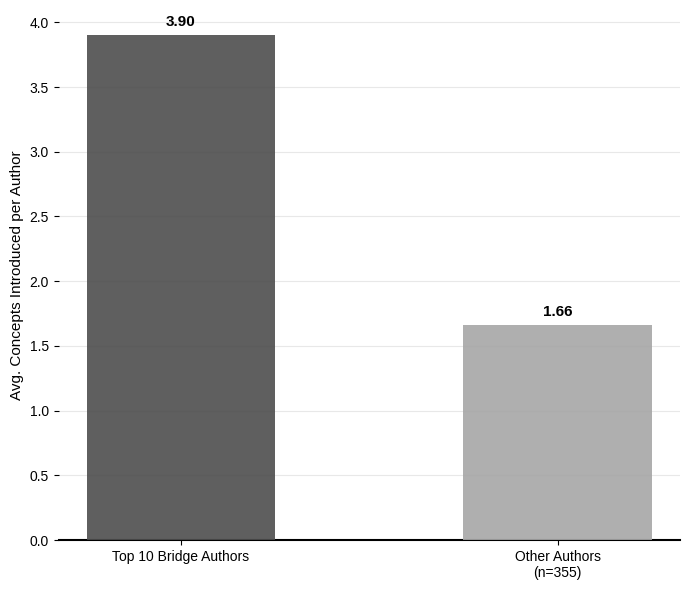

In [ ]:
import matplotlib.pyplot as plt

# --- 1. DYNAMIC CALCULATIONS ---
total_pioneer_authors = df_all_pioneers['Author'].nunique()
top_10_count = 10
other_count = total_pioneer_authors - top_10_count

concepts_top_10 = df_all_pioneers[df_all_pioneers['Is_Top_10']]['Concept'].nunique()
concepts_others = df_all_pioneers[~df_all_pioneers['Is_Top_10']]['Concept'].nunique()

avg_top_10 = concepts_top_10 / top_10_count
avg_others = concepts_others / other_count
avgs = [avg_top_10, avg_others]

# --- 2. PLOTTING ---
# Smaller, cleaner figure size
plt.figure(figsize=(7, 6))

categories = ['Top 10 Bridge Authors', f'Other Authors\n(n={other_count})']
values_avg = [avg_top_10, avg_others]
colors = ['#4D4D4D', '#A6A6A6']

# Create the bars
bars = plt.bar(categories, values_avg, color=colors, width=0.5, alpha=0.9, zorder=3)

# Style Adjustments
plt.ylabel("Avg. Concepts Introduced per Author", color='black', fontsize=11)

# Remove all grid lines except horizontal ones
plt.grid(False)
plt.gca().yaxis.grid(True, linestyle='-', which='major', color='lightgray', alpha=0.5, zorder=0)

# Remove top, right, and left spines (borders)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

# Make the bottom X-axis line prominent and black
plt.gca().spines['bottom'].set_visible(True)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['bottom'].set_linewidth(1.5)

# Ensure all text is pure black
plt.xticks(color='black', fontsize=10)
plt.yticks(color='black', fontsize=10)

# Add data labels on top of bars in black
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{height:.2f}', ha='center', va='bottom',
             fontweight='bold', fontsize=11, color='black')

# Final adjustments
plt.tight_layout()
plt.savefig("Innovation_Comparison_Minimal.pdf", transparent=True)
plt.show()

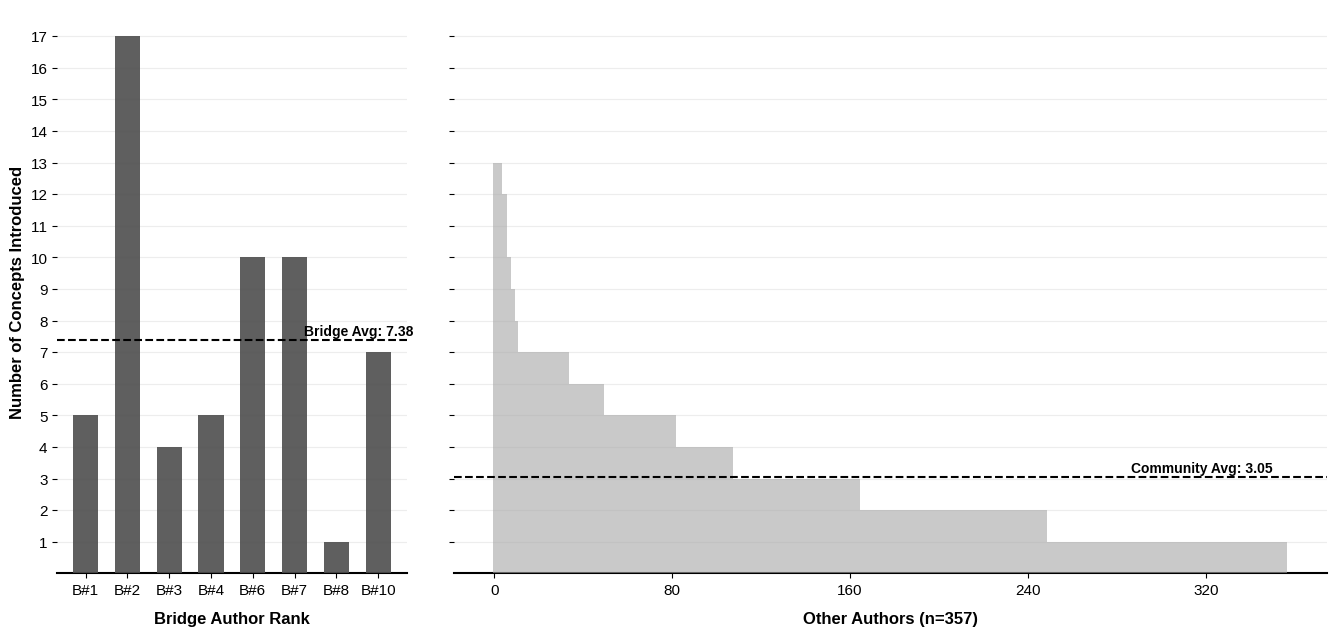

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator

# --- 1. DATA PREPARATION ---
# Group to get unique concept counts per author
pioneer_scores = df_all_pioneers.groupby(['Author', 'Is_Top_10', 'Rank'])['Concept'].nunique().reset_index()

# Separate the groups
bridge_data = pioneer_scores[pioneer_scores['Is_Top_10'] == True].sort_values('Rank')
other_data = pioneer_scores[pioneer_scores['Is_Top_10'] == False].sort_values('Concept', ascending=False)

# Calculate the mean for the community (the water level)
avg_bridge = bridge_data['Concept'].mean()
avg_others = other_data['Concept'].mean()
avgs = [avg_bridge, avg_others]

# --- 2. PLOTTING ---
# We use width_ratios to give the community tail more space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True, gridspec_kw={'width_ratios': [1, 2.5]})

# PANEL 1: Bridge Authors (Skyscrapers)
# x_bridge is now dynamic based on how many bridges actually pioneered concepts
x_bridge = np.arange(len(bridge_data))
ax1.bar(x_bridge, bridge_data['Concept'], color='#4D4D4D', alpha=0.9, width=0.6, zorder=3)

# Set ticks based on the actual data present
ax1.set_xticks(x_bridge)
ax1.set_xticklabels([f"B#{int(r)}" for r in bridge_data['Rank']], color='black', fontsize=10)

# PANEL 2: Remaining Authors (The Foundation)
x_other = np.arange(len(other_data))
ax2.bar(x_other, other_data['Concept'], color='#A6A6A6', alpha=0.6, width=1.0, zorder=3)
ax2.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))

# --- 3. ORTHOGONAL AVERAGE LINE & MINIMALIST STYLE ---
for idx, ax in enumerate([ax1, ax2]):
    # THE ORTHOGONAL LINE: Horizontal across vertical bars
    ax.axhline(avgs[idx], color='black', linestyle='--', linewidth=1.5, zorder=4)

    # Style Cleanup
    ax.grid(False)
    ax.yaxis.grid(True, linestyle='-', which='major', color='lightgray', alpha=0.4, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', colors='black', labelsize=11)

# Labels
ax1.set_ylabel("Number of Concepts Introduced", color='black', fontsize=12, fontweight='bold')
ax1.set_xlabel("Bridge Author Rank", color='black', fontsize=12, fontweight='bold', labelpad=10)
ax2.set_xlabel(f"Other Authors (n={len(other_data)})", color='black', fontsize=12, fontweight='bold', labelpad=10)

# Ensure Y-axis only shows whole numbers
ax1.set_yticks(range(1, int(pioneer_scores['Concept'].max()) + 1))

# Text annotation for the bridges
ax1.text(len(bridge_data)*0.98, avg_bridge + 0.05, f"Bridge Avg: {avg_bridge:.2f}",
         color='black', fontweight='bold', ha='right', va='bottom', fontsize=10)

# Text annotation for the average
ax2.text(len(other_data)*0.98, avg_others + 0.05, f"Community Avg: {avg_others:.2f}",
         color='black', fontweight='bold', ha='right', va='bottom', fontsize=10)

plt.tight_layout(pad=3.0)
plt.savefig("Innovation_LongTail_Corrected.pdf", transparent=True, dpi=300)
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


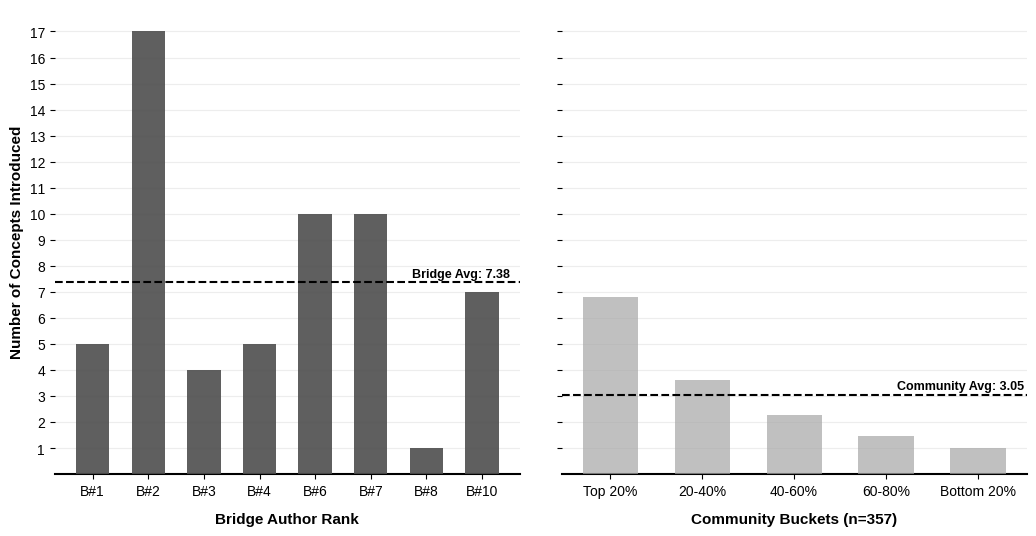

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator

# --- 1. DATA PREPARATION ---
# Group by author to get their 'Scouting Score' (Total unique concepts introduced)
# We assume 'df_all_pioneers' is already in your environment from the previous step
pioneer_scores = df_all_pioneers.groupby(['Author', 'Is_Top_10', 'Rank'])['Concept'].nunique().reset_index()

# Separate the Top 10 Bridges
bridge_data = pioneer_scores[pioneer_scores['Is_Top_10'] == True].sort_values('Rank')

# Group the 'Other Authors' into 5 Buckets (Quintiles) based on their Concept counts
other_data = pioneer_scores[pioneer_scores['Is_Top_10'] == False].sort_values('Concept', ascending=False).reset_index(drop=True)
# Split into 5 roughly equal buckets
other_buckets = np.array_split(other_data, 5)
bucket_means = [bucket['Concept'].mean() for bucket in other_buckets]

# Averages for the orthogonal lines
avg_bridge = bridge_data['Concept'].mean()
avg_others = other_data['Concept'].mean()

# --- 2. PLOTTING ---
# Using shared Y-axis and tight width ratios
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 6), sharey=True, gridspec_kw={'width_ratios': [1, 1]})

# PANEL 1: Top 10 Bridge Authors (Individual Bars)
x_bridge = np.arange(len(bridge_data))
ax1.bar(x_bridge, bridge_data['Concept'], color='#4D4D4D', alpha=0.9, width=0.6, zorder=3)
ax1.set_xticks(x_bridge)
ax1.set_xticklabels([f"B#{int(r)}" for r in bridge_data['Rank']], color='black', fontsize=9)
ax1.set_xlabel("Bridge Author Rank", color='black', fontsize=11, fontweight='bold', labelpad=10)

# PANEL 2: Remaining Authors (Bucketed in Quintiles)
x_buckets = np.arange(5)
ax2.bar(x_buckets, bucket_means, color='#A6A6A6', alpha=0.7, width=0.6, zorder=3)
ax2.set_xticks(x_buckets)
ax2.set_xticklabels(['Top 20%', '20-40%', '40-60%', '60-80%', 'Bottom 20%'], color='black', fontsize=9)
ax2.set_xlabel(f"Community Buckets (n={len(other_data)})", color='black', fontsize=11, fontweight='bold', labelpad=10)

# --- 3. ORTHOGONAL LINES & STYLE ---
# Horizontal Average for Bridges
ax1.axhline(avg_bridge, color='black', linestyle='--', linewidth=1.5, zorder=4)
ax1.text(len(bridge_data)-0.5, avg_bridge + 0.08, f"Bridge Avg: {avg_bridge:.2f}",
         color='black', fontweight='bold', ha='right', va='bottom', fontsize=9)

# Horizontal Average for Community
ax2.axhline(avg_others, color='black', linestyle='--', linewidth=1.5, zorder=4)
ax2.text(4.5, avg_others + 0.08, f"Community Avg: {avg_others:.2f}",
         color='black', fontweight='bold', ha='right', va='bottom', fontsize=9)

for ax in [ax1, ax2]:
    # Style Cleanup
    ax.grid(False)
    # Background horizontal lines for context
    ax.yaxis.grid(True, linestyle='-', which='major', color='lightgray', alpha=0.4, zorder=0)

    # Remove borders (spines)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Prominent black bottom line
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)

    # Pure black ticks
    ax.tick_params(axis='both', colors='black', labelsize=10)

# Labels
ax1.set_ylabel("Number of Concepts Introduced", color='black', fontsize=11, fontweight='bold')
ax1.set_yticks(range(1, int(pioneer_scores['Concept'].max()) + 1))

plt.tight_layout(pad=3.0)
plt.savefig("Innovation_Bucketed_Final.pdf", transparent=True, dpi=300)
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


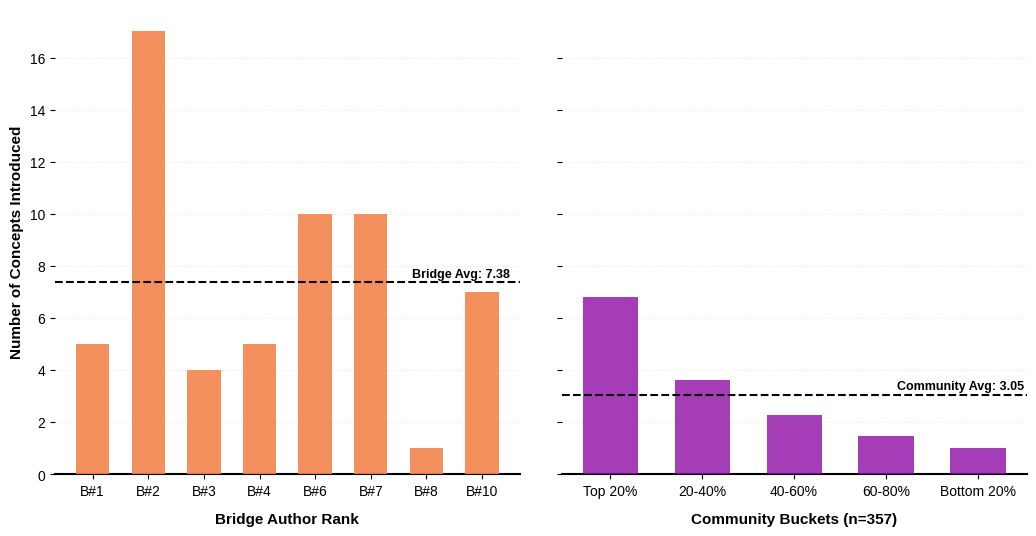

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm

# --- 1. DATA PREPARATION ---
pioneer_scores = df_all_pioneers.groupby(['Author', 'Is_Top_10', 'Rank'])['Concept'].nunique().reset_index()

# Separate the Top 10 Bridges
bridge_data = pioneer_scores[pioneer_scores['Is_Top_10'] == True].sort_values('Rank')

# Group the 'Other Authors' into 5 Buckets (Quintiles)
other_data = pioneer_scores[pioneer_scores['Is_Top_10'] == False].sort_values('Concept', ascending=False).reset_index(drop=True)
other_buckets = np.array_split(other_data, 5)
bucket_means = [bucket['Concept'].mean() for bucket in other_buckets]

# Averages for the orthogonal lines
avg_bridge = bridge_data['Concept'].mean()
avg_others = other_data['Concept'].mean()

# Colors from Plasma
color_bridge = cm.plasma(0.7)    # Vibrant Orange/Magenta
color_community = cm.plasma(0.3) # Deep Purple/Blue

# --- 2. PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 6), sharey=True, gridspec_kw={'width_ratios': [1, 1]})

# PANEL 1: Top 10 Bridge Authors
x_bridge = np.arange(len(bridge_data))
ax1.bar(x_bridge, bridge_data['Concept'], color=color_bridge, alpha=0.9, width=0.6, zorder=3)
ax1.set_xticks(x_bridge)
ax1.set_xticklabels([f"B#{int(r)}" for r in bridge_data['Rank']], color='black', fontsize=9)
ax1.set_xlabel("Bridge Author Rank", color='black', fontsize=11, fontweight='bold', labelpad=10)

# PANEL 2: Remaining Authors (Bucketed)
x_buckets = np.arange(5)
ax2.bar(x_buckets, bucket_means, color=color_community, alpha=0.8, width=0.6, zorder=3)
ax2.set_xticks(x_buckets)
ax2.set_xticklabels(['Top 20%', '20-40%', '40-60%', '60-80%', 'Bottom 20%'], color='black', fontsize=9)
ax2.set_xlabel(f"Community Buckets (n={len(other_data)})", color='black', fontsize=11, fontweight='bold', labelpad=10)

# --- 3. ORTHOGONAL LINES & STYLE ---
ax1.axhline(avg_bridge, color='black', linestyle='--', linewidth=1.5, zorder=4)
ax1.text(len(bridge_data)-0.5, avg_bridge + 0.08, f"Bridge Avg: {avg_bridge:.2f}",
         color='black', fontweight='bold', ha='right', va='bottom', fontsize=9)

ax2.axhline(avg_others, color='black', linestyle='--', linewidth=1.5, zorder=4)
ax2.text(4.5, avg_others + 0.08, f"Community Avg: {avg_others:.2f}",
         color='black', fontweight='bold', ha='right', va='bottom', fontsize=9)

for ax in [ax1, ax2]:
    ax.grid(False)
    ax.yaxis.grid(True, linestyle=':', which='major', color='lightgray', alpha=0.5, zorder=0)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)

    ax.tick_params(axis='both', colors='black', labelsize=10)

ax1.set_ylabel("Number of Concepts Introduced", color='black', fontsize=11, fontweight='bold')

plt.tight_layout(pad=3.0)
plt.savefig("Innovation_Bucketed_Final.pdf", transparent=True, dpi=300)
plt.savefig('Innovation_Bucketed_Final.svg', format='svg', bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
TR_START_YEAR = min(
    a.get('publication_year') for a in articles_tr if a.get('publication_year')
)

def analyze_concept_scouting_with_ranks(articles_tr, articles_global, results_df):
    df_ranks = results_df.sort_values('relative_bridge_score', ascending=False).reset_index(drop=True)
    df_ranks['Bridge_Rank'] = [f"B#{i+1}" for i in df_ranks.index]
    local_rank_map = dict(zip(df_ranks['author'], df_ranks['Bridge_Rank']))

    top_bridges_list = results_df.sort_values('relative_bridge_score', ascending=False).head(10)['author'].tolist()

    def get_first_arrival_years(articles):
        arrival = {}
        for art in articles:
            year = art.get('publication_year')
            concepts = [c.get('display_name') for c in art.get('concepts', [])]
            for concept in concepts:
                if concept and (concept not in arrival or year < arrival[concept]):
                    arrival[concept] = year
        return arrival

    global_arrival = get_first_arrival_years(articles_global)
    tr_arrival     = get_first_arrival_years(articles_tr)

    scouting_data = []
    for concept, tr_year in tr_arrival.items():
        if concept in global_arrival:
            global_year = global_arrival[concept]
            if global_year < TR_START_YEAR:
                continue
            lag = tr_year - global_year
            if lag > 0:
                for art in articles_tr:
                    if art.get('publication_year') == tr_year:
                        art_concepts = [c.get('display_name') for c in art.get('concepts', [])]
                        if concept in art_concepts:
                            authors = [a.get('author', {}).get('display_name') for a in art.get('authorships', [])]
                            for author in authors:
                                scouting_data.append({
                                    'Concept'     : concept,
                                    'Global_Start': int(global_year),
                                    'TR_Start'    : int(tr_year),
                                    'Lag_Years'   : int(lag),
                                    'Scout_Author': author,
                                    'Is_Bridge'   : author in top_bridges_list
                                })

    df = pd.DataFrame(scouting_data).drop_duplicates()
    df['Bridge_Rank'] = df['Scout_Author'].map(local_rank_map).fillna("-")
    return df


def analyze_full_network_scouting(articles_tr, articles_global, results_df):
    df_ranks = results_df.sort_values('relative_bridge_score', ascending=False).reset_index(drop=True)
    df_ranks['Bridge_Rank'] = df_ranks.index + 1
    rank_map = dict(zip(df_ranks['author'], df_ranks['Bridge_Rank']))

    def get_arrival_map(articles):
        arrival = {}
        for art in articles:
            year = art.get('publication_year')
            concepts = [c.get('display_name') for c in art.get('concepts', [])]
            for c in concepts:
                if c and (c not in arrival or year < arrival[c]):
                    arrival[c] = year
        return arrival

    global_arrival = get_arrival_map(articles_global)
    tr_arrival     = get_arrival_map(articles_tr)

    pioneering_events = []
    for concept, tr_year in tr_arrival.items():
        if concept in global_arrival:
            global_year = global_arrival[concept]
            if global_year < TR_START_YEAR:
                continue
            if tr_year > global_year:
                for art in articles_tr:
                    if art.get('publication_year') == tr_year:
                        art_concepts = [c.get('display_name') for c in art.get('concepts', [])]
                        if concept in art_concepts:
                            authors = [a.get('author', {}).get('display_name') for a in art.get('authorships', [])]
                            for author in authors:
                                pioneering_events.append({
                                    'Concept'   : concept,
                                    'Author'    : author,
                                    'Rank'      : rank_map.get(author, 999),
                                    'Is_Top_10' : rank_map.get(author, 999) <= 10
                                })

    return pd.DataFrame(pioneering_events).drop_duplicates()


# --- Execution (same as before) ---
df_scouting_final = analyze_concept_scouting_with_ranks(articles_tr, articles_global, df_tr_results)
bridge_pioneered  = df_scouting_final[df_scouting_final['Is_Bridge'] == True].copy()

print(f"TR data starts: {TR_START_YEAR}")
print(f"Total Innovations Introduced to Turkey: {df_scouting_final['Concept'].nunique()}")
print(f"Innovations Pioneered by a Top 10 Bridge: {bridge_pioneered['Concept'].nunique()}")

df_all_pioneers = analyze_full_network_scouting(articles_tr, articles_global, df_tr_results)

TR data starts: 2010
Total Innovations Introduced to Turkey: 303
Innovations Pioneered by a Top 10 Bridge: 20


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


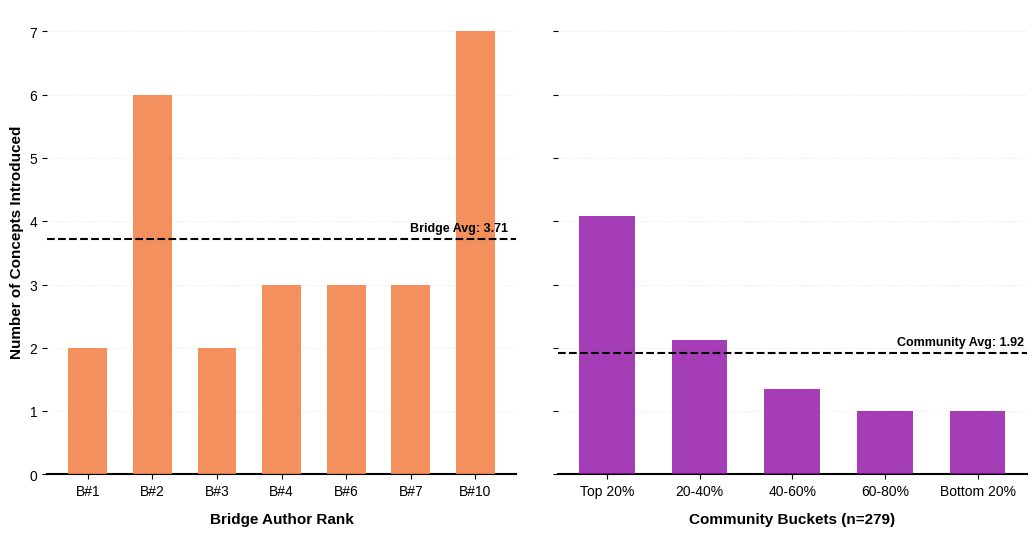

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm

# --- 1. DATA PREPARATION ---
pioneer_scores = df_all_pioneers.groupby(['Author', 'Is_Top_10', 'Rank'])['Concept'].nunique().reset_index()

# Separate the Top 10 Bridges
bridge_data = pioneer_scores[pioneer_scores['Is_Top_10'] == True].sort_values('Rank')

# Group the 'Other Authors' into 5 Buckets (Quintiles)
other_data = pioneer_scores[pioneer_scores['Is_Top_10'] == False].sort_values('Concept', ascending=False).reset_index(drop=True)
other_buckets = np.array_split(other_data, 5)
bucket_means = [bucket['Concept'].mean() for bucket in other_buckets]

# Averages for the orthogonal lines
avg_bridge = bridge_data['Concept'].mean()
avg_others = other_data['Concept'].mean()

# Colors from Plasma
color_bridge = cm.plasma(0.7)    # Vibrant Orange/Magenta
color_community = cm.plasma(0.3) # Deep Purple/Blue

# --- 2. PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 6), sharey=True, gridspec_kw={'width_ratios': [1, 1]})

# PANEL 1: Top 10 Bridge Authors
x_bridge = np.arange(len(bridge_data))
ax1.bar(x_bridge, bridge_data['Concept'], color=color_bridge, alpha=0.9, width=0.6, zorder=3)
ax1.set_xticks(x_bridge)
ax1.set_xticklabels([f"B#{int(r)}" for r in bridge_data['Rank']], color='black', fontsize=9)
ax1.set_xlabel("Bridge Author Rank", color='black', fontsize=11, fontweight='bold', labelpad=10)

# PANEL 2: Remaining Authors (Bucketed)
x_buckets = np.arange(5)
ax2.bar(x_buckets, bucket_means, color=color_community, alpha=0.8, width=0.6, zorder=3)
ax2.set_xticks(x_buckets)
ax2.set_xticklabels(['Top 20%', '20-40%', '40-60%', '60-80%', 'Bottom 20%'], color='black', fontsize=9)
ax2.set_xlabel(f"Community Buckets (n={len(other_data)})", color='black', fontsize=11, fontweight='bold', labelpad=10)

# --- 3. ORTHOGONAL LINES & STYLE ---
ax1.axhline(avg_bridge, color='black', linestyle='--', linewidth=1.5, zorder=4)
ax1.text(len(bridge_data)-0.5, avg_bridge + 0.08, f"Bridge Avg: {avg_bridge:.2f}",
         color='black', fontweight='bold', ha='right', va='bottom', fontsize=9)

ax2.axhline(avg_others, color='black', linestyle='--', linewidth=1.5, zorder=4)
ax2.text(4.5, avg_others + 0.08, f"Community Avg: {avg_others:.2f}",
         color='black', fontweight='bold', ha='right', va='bottom', fontsize=9)

for ax in [ax1, ax2]:
    ax.grid(False)
    ax.yaxis.grid(True, linestyle=':', which='major', color='lightgray', alpha=0.5, zorder=0)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)

    ax.tick_params(axis='both', colors='black', labelsize=10)

ax1.set_ylabel("Number of Concepts Introduced", color='black', fontsize=11, fontweight='bold')

plt.tight_layout(pad=3.0)
plt.savefig("Innovation_Bucketed_Final.pdf", transparent=True, dpi=300)
plt.show()